# Honeywell Temperature Alarm Prediction — Advanced EDA
## Comprehensive Exploratory Data Analysis & Client-Driven Analysis Report

**Purpose:** This notebook performs an in-depth, multi-faceted EDA per client specifications.  
**Scope:** Pure analysis only — no model training, no feature engineering for models.

### Analysis Roadmap:
1. Data Loading & Overview
2. Timestamp Frequency & Gap Analysis
3. Missing Value Summary
4. Consecutive Null Analysis & Imputation Strategy
5. Pre-Imputation Correlation Analysis (Pearson, Spearman, Distance)
6. SME Variable Removal Placeholder
7. Data Imputation Pipeline (MICE / Forward-Fill)
8. Alarm Episode Detection & Duration Windowing
9. Pre-Alarm & Post-Alarm Behavior Analysis
10. Post-Trip False Alarm Verification
11. Alarm Distribution Across Train/Val/Test Splits
12. Monthly & Seasonal Alarm Trends
13. Executive Summary & Recommendations

---

In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from itertools import combinations

# Add utility path for client-provided PreprocessingUtility
sys.path.insert(0, os.path.join(os.getcwd(), '03TIC_1023_PVHI', '03TIC_1023_PVHI', 'UTILITY_CLASSES'))

from PreprocessingUtility import (
    save_output_to_csv,
    save_output_to_parquet,
    null_summary,
    get_consecutive_nulls,
    detect_events,
    plot_tags_trend,
    plot_correlation,
    plot_spearman_correlation,
    plot_distance_correlation
)

# Style settings
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13
sns.set_style("whitegrid")
print("✅ All imports successful.")

✅ All imports successful.


In [2]:
# ══════════════════════════════════════════════════
#  CONFIGURATION
# ══════════════════════════════════════════════════
TARGET_TAG      = "03TIC_1023.PV"
ALARM_THRESHOLD = 21.0
ALARM_CONDITION = "PVHI"
FFILL_LIMIT     = 5         # Forward-fill limit in minutes
MICE_THRESHOLD  = 60        # % null above which MICE is used instead of ffill
CORR_THRESHOLD  = 0.80      # Correlation threshold for pair flagging

# SME Feature Selection Override
# Specify features to remove here (e.g., ['03TI_1015.PV']):
SME_DROP_FEATURES = []

# File paths
DATA_PATH = os.path.join("03TIC_1023_PVHI", "03TIC_1023_PVHI",
                         "03TIC_1023_Final_merged_TripDataRemoved.parquet")
TRIP_PATH = os.path.join("03TIC_1023_PVHI", "03TIC_1023_PVHI",
                         "Final_Trip_Duration - Copy.csv")
TAG_CONFIG_PATH = os.path.join("03TIC_1023_PVHI", "03TIC_1023_PVHI",
                               "03TIC_1023_PVLO_PVHI.csv")

# Output directory
OUTPUT_DIR = os.path.join("outputs", "eda_reports")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Chronological split boundaries (for alarm distribution check)
TRAIN_END = pd.Timestamp("2025-06-12 23:59:00")
VAL_END   = pd.Timestamp("2025-08-09 23:59:00")

print(f"Target Tag:       {TARGET_TAG}")
print(f"Alarm Threshold:  {ALARM_THRESHOLD}°C ({ALARM_CONDITION})")
print(f"Output Directory: {OUTPUT_DIR}")

Target Tag:       03TIC_1023.PV
Alarm Threshold:  21.0°C (PVHI)
Output Directory: outputs\eda_reports


---
## 1. Data Loading & Overview

In [3]:
# Load the parquet dataset
df = pd.read_parquet(DATA_PATH)
df['TimeStamp'] = pd.to_datetime(df['TimeStamp'])
df = df.sort_values('TimeStamp').reset_index(drop=True)

print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Time Range:    {df['TimeStamp'].min()} → {df['TimeStamp'].max()}")
print(f"Duration:      {(df['TimeStamp'].max() - df['TimeStamp'].min()).days} days")
print()
df.info()

Dataset Shape: 2,019,221 rows × 20 columns
Time Range:    2022-01-03 22:45:00 → 2026-01-09 23:29:00
Duration:      1467 days

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2019221 entries, 0 to 2019220
Data columns (total 20 columns):
 #   Column         Dtype         
---  ------         -----         
 0   TimeStamp      datetime64[ns]
 1   02FI_1000.PV   float64       
 2   03FIC_1085.PV  float64       
 3   03LIC_1016.PV  float64       
 4   03LIC_1034.PV  float64       
 5   03PDI_1020.PV  float64       
 6   03PDI_1077.PV  float64       
 7   03PIC_1013.PV  float64       
 8   03PIC_1023.PV  float64       
 9   03PIC_1068.PV  float64       
 10  03PI_1409.PV   float64       
 11  03TIC_1009.PV  float64       
 12  03TIC_1023.PV  float64       
 13  03TIC_1145.PV  float64       
 14  03TI_1002.PV   float64       
 15  03TI_1005.PV   float64       
 16  03TI_1015.PV   float64       
 17  03TI_1024.PV   float64       
 18  03TI_1081.PV   float64       
 19  03TI_1108.PV   float6

In [4]:
# Statistical summary of all sensor columns
df.describe().round(4)

,TimeStamp,02FI_1000.PV,03FIC_1085.PV,03LIC_1016.PV,03LIC_1034.PV,03PDI_1020.PV,03PDI_1077.PV,03PIC_1013.PV,03PIC_1023.PV,03PIC_1068.PV,03PI_1409.PV,03TIC_1009.PV,03TIC_1023.PV,03TIC_1145.PV,03TI_1002.PV,03TI_1005.PV,03TI_1015.PV,03TI_1024.PV,03TI_1081.PV,03TI_1108.PV
count,2019221,2.018552e+06,2.018906e+06,2.019213e+06,2.019217e+06,2.019213e+06,2.019209e+06,2.019210e+06,2.019213e+06,2.019213e+06,2.019214e+06,2.019217e+06,2.019217e+06,2.019210e+06,2.016180e+06,2.019216e+06,2.019217e+06,2.019217e+06,2.019216e+06,2.019213e+06
mean,2024-01-05 23:37:03.643583232,8.224900e+00,2.677375e+02,4.078610e+01,5.370490e+01,2.480247e+02,3.040000e-01,2.169267e+02,6.602600e+00,2.341670e+01,2.611090e+01,4.243730e+01,1.787350e+01,2.692140e+01,5.287560e+01,4.975660e+01,1.640730e+01,1.705320e+01,-3.282530e+01,3.769090e+01
min,2022-01-03 22:45:00,0.000000e+00,2.983000e-01,1.792000e-01,-9.390000e-02,-7.020200e+00,-1.230000e-02,3.370900e+00,2.300000e-03,2.057200e+01,2.970000e-02,-1.989790e+01,5.800000e-03,4.531200e+00,2.578600e+01,2.836850e+01,-7.493380e+01,-1.453100e+00,-4.029110e+01,2.127190e+01
25%,2023-01-01 15:28:00,8.189500e+00,2.476325e+02,3.836080e+01,4.919960e+01,2.448009e+02,2.911000e-01,1.781777e+02,6.449100e+00,2.315050e+01,2.595440e+01,3.962720e+01,1.706550e+01,2.238830e+01,4.966300e+01,4.660540e+01,1.562230e+01,1.632380e+01,-3.369220e+01,3.440650e+01
50%,2024-01-07 00:46:00,8.476600e+00,2.655732e+02,4.082260e+01,5.404990e+01,2.599170e+02,3.172000e-01,2.109168e+02,6.574800e+00,2.332420e+01,2.613280e+01,4.191010e+01,1.787350e+01,2.509860e+01,5.240780e+01,4.909570e+01,1.641740e+01,1.703150e+01,-3.301250e+01,3.590110e+01
75%,2025-01-14 22:28:00,8.601100e+00,2.860708e+02,4.324690e+01,5.869290e+01,2.673335e+02,3.334000e-01,2.614219e+02,6.701700e+00,2.355830e+01,2.630450e+01,4.472420e+01,1.828610e+01,3.001110e+01,5.582690e+01,5.251400e+01,1.691430e+01,1.752220e+01,-3.221950e+01,4.057750e+01
max,2026-01-09 23:29:00,1.000000e+01,4.509887e+02,1.007093e+02,1.030420e+02,5.173429e+02,1.011600e+00,3.182620e+02,1.131930e+01,2.638230e+01,2.771800e+01,7.001710e+01,4.030710e+01,6.277500e+01,8.407280e+01,7.479400e+01,5.625420e+01,4.256460e+01,9.995660e+01,5.863750e+01
std,NaN,6.877000e-01,3.131010e+01,3.550100e+00,5.244400e+00,3.387040e+01,4.920000e-02,6.211490e+01,2.933000e-01,4.550000e-01,3.107000e-01,4.725700e+00,1.419900e+00,5.296700e+00,4.263500e+00,4.226100e+00,1.380500e+00,1.360100e+00,1.746800e+00,5.433800e+00


In [5]:
# Load DCS tag configuration (alarm limits)
try:
    tag_config = pd.read_csv(TAG_CONFIG_PATH)
    print("DCS Tag Configuration (alarm limits):")
    display(tag_config)
except Exception as e:
    print(f"Could not load tag config: {e}")
    tag_config = None

DCS Tag Configuration (alarm limits):


,DCS Tag Name,Description,EXT PV HIGH,PV HIGH,EXT PV LOW,PV LOW
0,03TI_1108,3C105 BOTTOM O/L TEMP,109.3750,100.0,-23.000,-20
1,03TI_1002,3C114 TEMP,106.2500,100.0,-2.500,0
2,03TIC_1009,3E102 O/L TO 3C105 TEMP,NaN,100.0,NaN,-20
3,03LIC_1016,3E104 LEVEL,NaN,100.0,NaN,0
4,03TI_1005,3E102 TUBE I/L TEMP,106.2500,100.0,-2.500,0
5,03PIC_1023,C3 3E104 TO 3C107 PRES,NaN,12.0,NaN,0
6,03TI_1015,C3 I/L TO 3E104 TEMP T/C,110.9400,100.0,-79.370,-75
7,03PDI_1020,DP ACROSS 3E104,637.5000,600.0,-15.000,0
8,03PI_1409,3C101 GAS TO 3C111 PRES,37.1870,35.0,-0.875,0
9,03TIC_1023,3C101 OVHD TO 3V101 TEMP,NaN,60.0,NaN,0


In [6]:
# Load trip/shutdown data
trip_df = pd.read_csv(TRIP_PATH)
# Normalize column names
trip_df.columns = trip_df.columns.str.strip()
# Parse dates — the file has 'Stop Date' and 'Start Date' columns
for col in trip_df.columns:
    try:
        trip_df[col] = pd.to_datetime(trip_df[col])
    except:
        pass

# Ensure proper ordering: trip_start < trip_end
if 'Stop Date' in trip_df.columns and 'Start Date' in trip_df.columns:
    trip_df['trip_start'] = trip_df[['Stop Date', 'Start Date']].min(axis=1)
    trip_df['trip_end']   = trip_df[['Stop Date', 'Start Date']].max(axis=1)
else:
    trip_df.columns = ['trip_start', 'trip_end']
    trip_df['trip_start'] = pd.to_datetime(trip_df['trip_start'])
    trip_df['trip_end']   = pd.to_datetime(trip_df['trip_end'])

trip_df['duration_hours'] = (trip_df['trip_end'] - trip_df['trip_start']).dt.total_seconds() / 3600
print(f"Loaded {len(trip_df)} trip/shutdown records")
print(f"Trip date range: {trip_df['trip_start'].min()} → {trip_df['trip_end'].max()}")
trip_df[['trip_start', 'trip_end', 'duration_hours']].head(10)

Loaded 84 trip/shutdown records
Trip date range: 2022-01-23 04:50:00 → 2025-08-20 01:02:00


,trip_start,trip_end,duration_hours
0,2022-01-23 19:10:00,2022-01-23 22:26:00,3.266667
1,2022-04-18 13:06:00,2022-04-19 00:55:00,11.816667
2,2022-04-18 13:06:00,2022-04-19 02:35:00,13.483333
3,2022-04-18 13:06:00,2022-04-18 15:40:00,2.566667
4,2023-01-04 09:42:00,2023-01-04 09:52:00,0.166667
5,2023-03-09 05:53:00,2023-03-09 10:00:00,4.116667
6,2023-03-09 06:00:00,2023-03-09 22:00:00,16.000000
7,2024-01-01 14:17:00,2024-01-01 23:55:00,9.633333
8,2024-01-01 15:30:00,2024-01-01 17:00:00,1.500000
9,2022-01-23 04:50:00,2022-01-23 06:30:00,1.666667


---
## 2. Timestamp Frequency & Gap Analysis

Verify the sampling frequency is regular (1-minute intervals) and identify gaps from shutdowns/trips.

In [7]:
# Compute time deltas between consecutive rows
deltas = df['TimeStamp'].diff().dt.total_seconds() / 60  # in minutes
deltas_clean = deltas.dropna()

print("=== Timestamp Delta Statistics (minutes) ===")
print(f"  Median:  {deltas_clean.median():.2f} min")
print(f"  Mean:    {deltas_clean.mean():.2f} min")
print(f"  Std:     {deltas_clean.std():.2f} min")
print(f"  Max:     {deltas_clean.max():.2f} min ({deltas_clean.max()/60:.1f} hours, {deltas_clean.max()/1440:.1f} days)")
print(f"  Min:     {deltas_clean.min():.4f} min")
print()
print(f"  Gaps > 5 min:   {(deltas_clean > 5).sum():,}")
print(f"  Gaps > 60 min:  {(deltas_clean > 60).sum():,}")
print(f"  Gaps > 1440 min (1 day): {(deltas_clean > 1440).sum():,}")

=== Timestamp Delta Statistics (minutes) ===
  Median:  1.00 min
  Mean:    1.05 min


  Std:     22.31 min
  Max:     26782.00 min (446.4 hours, 18.6 days)
  Min:     1.0000 min

  Gaps > 5 min:   45
  Gaps > 60 min:  44
  Gaps > 1440 min (1 day): 15


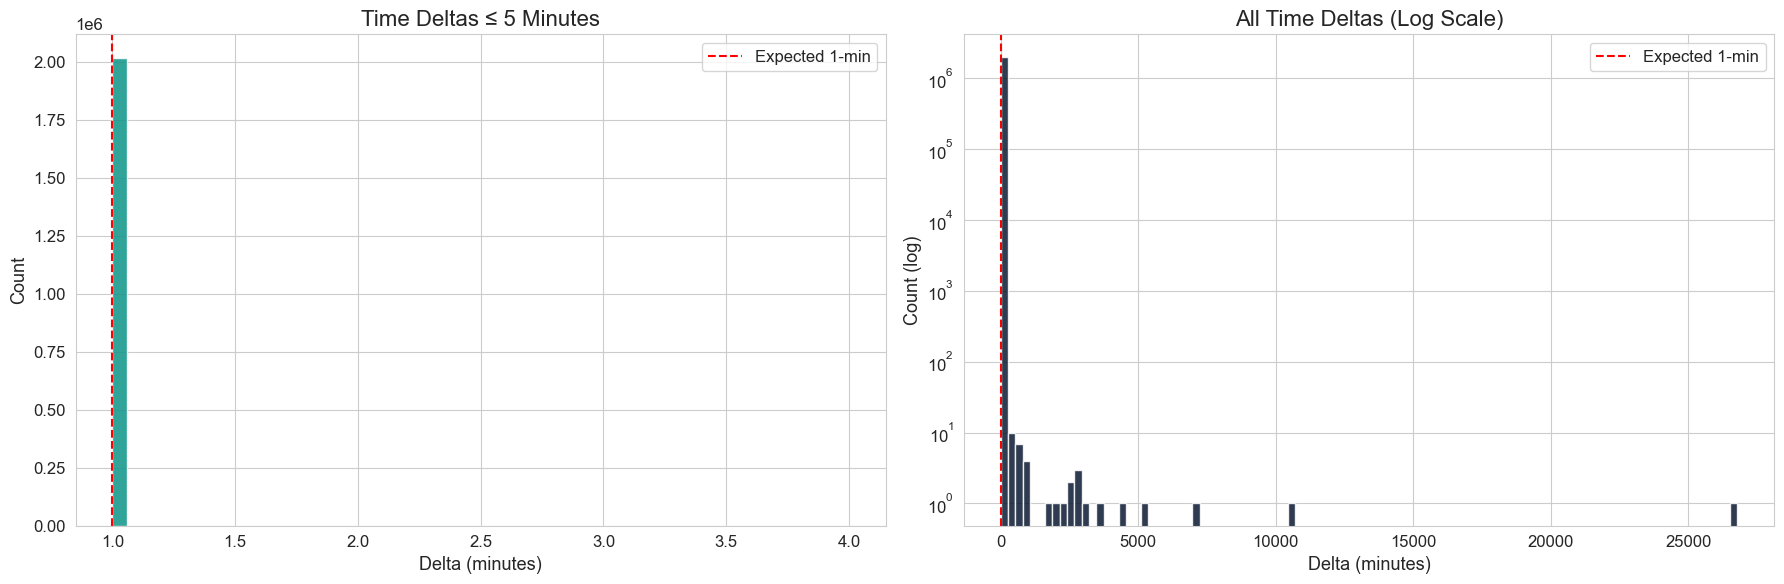

Saved: timestamp_gap_histogram.png


In [8]:
# Histogram of time deltas (log scale for long tail)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Normal-range deltas
axes[0].hist(deltas_clean[deltas_clean <= 5], bins=50, color='#0D9488', edgecolor='white', alpha=0.85)
axes[0].set_title("Time Deltas ≤ 5 Minutes")
axes[0].set_xlabel("Delta (minutes)")
axes[0].set_ylabel("Count")
axes[0].axvline(1.0, color='red', linestyle='--', linewidth=1.5, label='Expected 1-min')
axes[0].legend()

# All deltas (log scale)
axes[1].hist(deltas_clean, bins=100, color='#0A1931', edgecolor='white', alpha=0.85, log=True)
axes[1].set_title("All Time Deltas (Log Scale)")
axes[1].set_xlabel("Delta (minutes)")
axes[1].set_ylabel("Count (log)")
axes[1].axvline(1.0, color='red', linestyle='--', linewidth=1.5, label='Expected 1-min')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "timestamp_gap_histogram.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: timestamp_gap_histogram.png")

In [9]:
# Top 20 largest gaps
large_gaps = deltas_clean[deltas_clean > 5].sort_values(ascending=False).head(20)
gap_report = pd.DataFrame({
    'Gap_Start': df['TimeStamp'].iloc[large_gaps.index - 1].values,
    'Gap_End':   df['TimeStamp'].iloc[large_gaps.index].values,
    'Gap_Minutes': large_gaps.values,
    'Gap_Hours':   (large_gaps.values / 60).round(2),
    'Gap_Days':    (large_gaps.values / 1440).round(2)
})
gap_report = gap_report.sort_values('Gap_Minutes', ascending=False).reset_index(drop=True)
save_output_to_csv(gap_report, OUTPUT_DIR, "top_gaps_report.csv")
print("Top 20 Largest Gaps:")
display(gap_report)

Saved to outputs\eda_reports\top_gaps_report.csv
Top 20 Largest Gaps:


,Gap_Start,Gap_End,Gap_Minutes,Gap_Hours,Gap_Days
0,2024-12-03 23:59:00,2024-12-22 14:21:00,26782.0,446.37,18.60
1,2023-11-28 14:14:00,2023-12-05 23:58:00,10664.0,177.73,7.41
2,2023-06-26 07:59:00,2023-07-01 04:31:00,6992.0,116.53,4.86
3,2024-07-02 04:09:00,2024-07-05 20:41:00,5312.0,88.53,3.69
4,2025-02-19 22:29:00,2025-02-22 22:30:00,4321.0,72.02,3.00
5,2022-10-19 23:11:00,2022-10-22 09:57:00,3526.0,58.77,2.45
6,2022-12-19 18:49:00,2022-12-21 22:30:00,3101.0,51.68,2.15
7,2023-03-01 22:29:00,2023-03-03 22:30:00,2881.0,48.02,2.00
8,2025-07-11 22:29:00,2025-07-13 22:30:00,2881.0,48.02,2.00
9,2022-03-01 23:44:00,2022-03-03 21:46:00,2762.0,46.03,1.92


---
## 3. Missing Value Summary

Analyze null counts and percentages per column using the client's `PreprocessingUtility`.

In [10]:
# Use the client utility function
null_df = null_summary(df)
display(null_df)

# Classify columns by null severity
all_cols = [c for c in df.columns if c != 'TimeStamp']
null_pct = (df[all_cols].isnull().sum() / len(df) * 100).round(4)

classification = pd.DataFrame({
    'Column': null_pct.index,
    'Null_Count': df[all_cols].isnull().sum().values,
    'Null_Percentage': null_pct.values
})
classification['Category'] = pd.cut(
    classification['Null_Percentage'],
    bins=[-0.001, 0.01, 1.0, 10.0, 100.0],
    labels=['Clean (<0.01%)', 'Minor (0.01-1%)', 'Moderate (1-10%)', 'Severe (>10%)']
)
classification = classification.sort_values('Null_Percentage', ascending=False)
save_output_to_csv(classification, OUTPUT_DIR, "null_summary_report.csv")
print("\nNull Classification Summary:")
print(classification['Category'].value_counts().to_string())

Total rows: 2019221
Columns with nulls: 19 / 19


,Null_Count,Null_Percentage
03TI_1002.PV,3041,0.15
02FI_1000.PV,669,0.03
03FIC_1085.PV,315,0.02
03LIC_1016.PV,8,0.00
03LIC_1034.PV,4,0.00
03PDI_1077.PV,12,0.00
03PDI_1020.PV,8,0.00
03PIC_1023.PV,8,0.00
03PIC_1068.PV,8,0.00
03PI_1409.PV,7,0.00


Saved to outputs\eda_reports\null_summary_report.csv

Null Classification Summary:
Category
Clean (<0.01%)      16
Minor (0.01-1%)      3
Moderate (1-10%)     0
Severe (>10%)        0


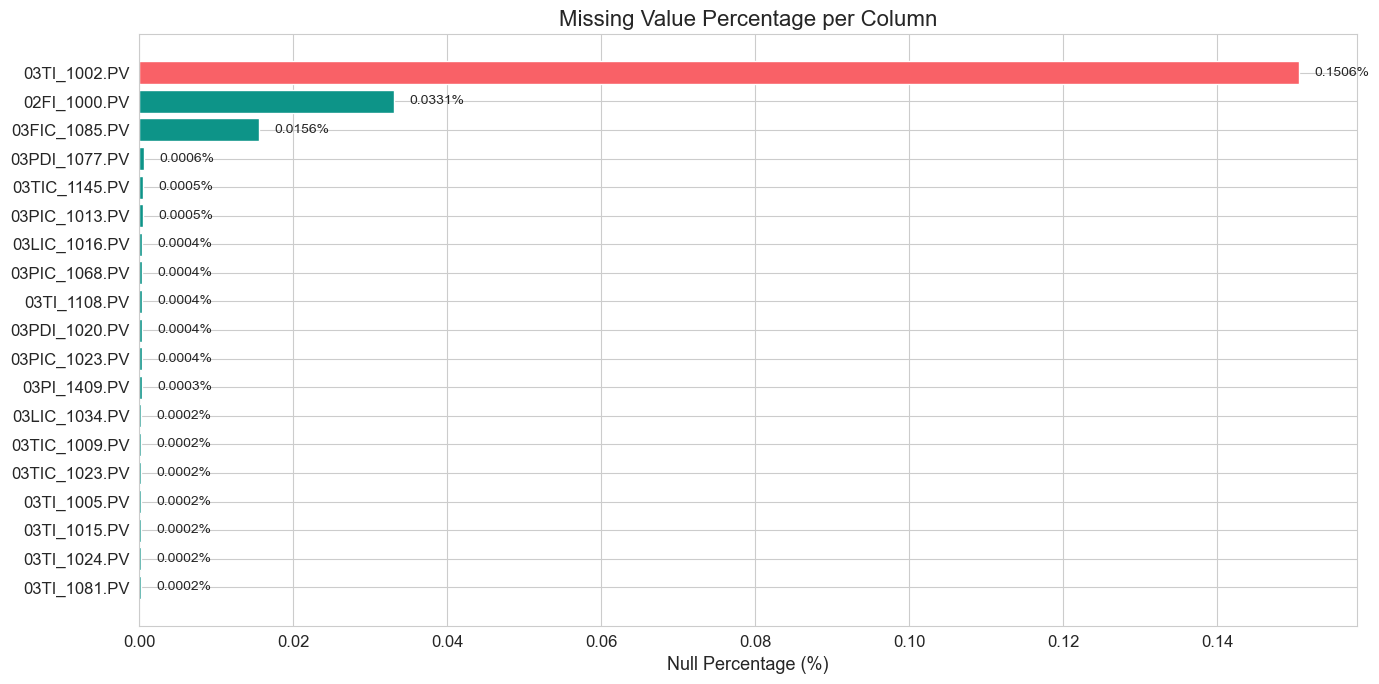

Saved: null_percentages.png


In [11]:
# Visual: Null percentages per column
fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#0D9488' if v < 0.1 else '#F96167' for v in classification['Null_Percentage']]
bars = ax.barh(classification['Column'], classification['Null_Percentage'], color=colors, edgecolor='white')
ax.set_xlabel("Null Percentage (%)")
ax.set_title("Missing Value Percentage per Column")
ax.invert_yaxis()
for bar, val in zip(bars, classification['Null_Percentage']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.4f}%',
            va='center', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "null_percentages.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: null_percentages.png")

---
## 3.5. DCS Operational Limits & Outlier Analysis

The client provided operational configuration limits for each tag in `03TIC_1023_PVLO_PVHI.csv`. We check:
- **Normal Warning Limits (`PV LOW` to `PV HIGH`)**: Check if process variables cross these normal operating thresholds.
- **Extreme Trip Limits (`EXT PV LOW` to `EXT PV HIGH`)**: Any crossing of these extreme boundaries represents physical outliers or sensor malfunctions in the operational data.

We verify these ranges against the post-trip operational dataset (2,019,221 rows) after trip transients have been cleaned.


Saved: outputs\eda_reports\sensor_limits_analysis.csv


,Tag,Description,PV_LOW,PV_HIGH,EXT_LOW,EXT_HIGH,Total_Rows,Normal_Crossed,Normal_Crossed_Pct,Extreme_Breached,Extreme_Breached_Pct
17,03PIC_1013.PV,3K101 1ST STAG SUC PRES,0.0,300.0,NaN,NaN,2019210,279708,13.852348,0,0.0
13,03PDI_1077.PV,DP ACROSS 3E107,0.0,1.0,-0.025,1.0625,2019209,194,0.009608,0,0.0
3,03LIC_1016.PV,3E104 LEVEL,0.0,100.0,NaN,NaN,2019213,6,0.000297,0,0.0
11,03LIC_1034.PV,3C101 H/C LEVEL,0.0,100.0,NaN,NaN,2019217,4,0.000198,0,0.0
7,03PDI_1020.PV,DP ACROSS 3E104,0.0,600.0,-15.000,637.5000,2019213,2,0.000099,0,0.0
10,03TI_1024.PV,3C101 I/L TEMP,0.0,100.0,-2.500,106.2500,2019217,2,0.000099,0,0.0


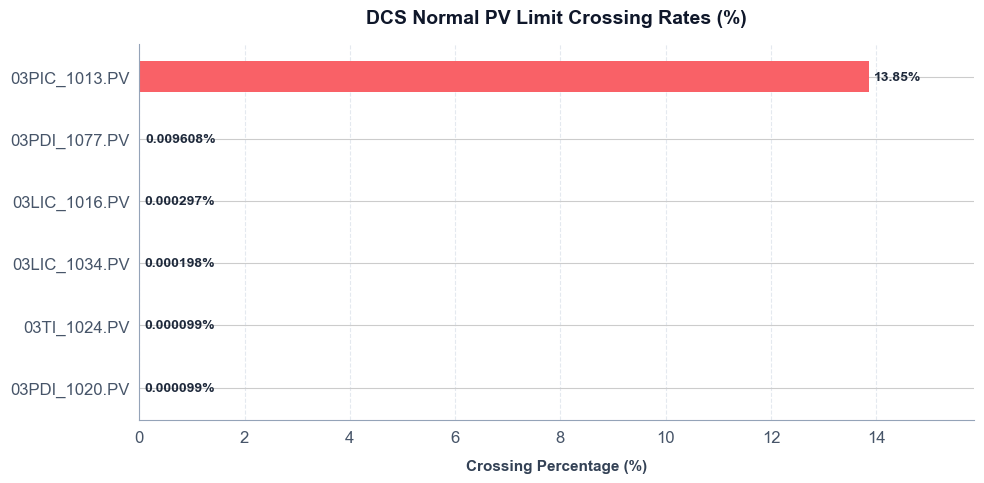

In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load limits configuration
limits_path = os.path.join("03TIC_1023_PVHI", "03TIC_1023_PVHI", "03TIC_1023_PVLO_PVHI.csv")
limits_df = pd.read_csv(limits_path)

results = []
for _, row in limits_df.iterrows():
    tag_base = row['DCS Tag Name']
    tag_col = f"{tag_base}.PV"
    
    if tag_col not in df.columns:
        continue
        
    values = df[tag_col].dropna()
    total_non_null = len(values)
    if total_non_null == 0:
        continue
        
    # Limits
    pv_high = float(row['PV HIGH']) if pd.notnull(row['PV HIGH']) else np.nan
    pv_low = float(row['PV LOW']) if pd.notnull(row['PV LOW']) else np.nan
    ext_high = float(row['EXT PV HIGH']) if pd.notnull(row['EXT PV HIGH']) else np.nan
    ext_low = float(row['EXT PV LOW']) if pd.notnull(row['EXT PV LOW']) else np.nan
    
    # Check crossings
    crossed_high = (values > pv_high).sum() if pd.notnull(pv_high) else 0
    crossed_low = (values < pv_low).sum() if pd.notnull(pv_low) else 0
    total_crossed = int(crossed_high + crossed_low)
    crossed_pct = (total_crossed / total_non_null) * 100
    
    # Check extreme breaches (outliers)
    breached_high = (values > ext_high).sum() if pd.notnull(ext_high) else 0
    breached_low = (values < ext_low).sum() if pd.notnull(ext_low) else 0
    total_breached = int(breached_high + breached_low)
    breached_pct = (total_breached / total_non_null) * 100
    
    results.append({
        'Tag': tag_col,
        'Description': row['Description'],
        'PV_LOW': pv_low,
        'PV_HIGH': pv_high,
        'EXT_LOW': ext_low,
        'EXT_HIGH': ext_high,
        'Total_Rows': total_non_null,
        'Normal_Crossed': total_crossed,
        'Normal_Crossed_Pct': round(crossed_pct, 6),
        'Extreme_Breached': total_breached,
        'Extreme_Breached_Pct': round(breached_pct, 6)
    })
    
res_df = pd.DataFrame(results)

# Save summary
csv_path = os.path.join(OUTPUT_DIR, "sensor_limits_analysis.csv")
res_df.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")

# Display summary table for non-zero crossings or all
display(res_df[res_df['Normal_Crossed'] > 0].sort_values('Normal_Crossed_Pct', ascending=False))

# Plot limits crossings
plot_df = res_df[res_df['Normal_Crossed'] > 0].copy()
plot_df = plot_df.sort_values('Normal_Crossed_Pct', ascending=True)

plt.figure(figsize=(10, 5))
colors = ['#0D9488' if pct < 1.0 else '#F96167' for pct in plot_df['Normal_Crossed_Pct']]
bars = plt.barh(plot_df['Tag'], plot_df['Normal_Crossed_Pct'], color=colors, edgecolor='none', height=0.5)

for bar in bars:
    width = bar.get_width()
    label_text = f"{width:.6f}%" if width < 0.1 else f"{width:.2f}%"
    plt.text(width + 0.1, bar.get_y() + bar.get_height()/2, label_text, 
             va='center', ha='left', fontsize=10, fontweight='bold', color='#1E293B')
             
plt.title("DCS Normal PV Limit Crossing Rates (%)", fontsize=14, fontweight='bold', pad=15, color='#0F172A')
plt.xlabel("Crossing Percentage (%)", fontsize=11, fontweight='bold', labelpad=10, color='#334155')
plt.xlim(0, max(plot_df['Normal_Crossed_Pct'].max() + 2.0, 15.0))
plt.grid(axis='x', linestyle='--', alpha=0.5, color='#CBD5E1')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#94A3B8')
ax.spines['bottom'].set_color('#94A3B8')
ax.tick_params(colors='#475569')

plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, "sensor_limits_analysis.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()


---
## 4. Consecutive Null Analysis & Imputation Strategy

Identify consecutive null value periods per column and determine the imputation strategy:
- **Max consecutive null duration > 60 minutes** → MICE Imputation
- **Max consecutive null duration ≤ 60 minutes** → Forward-Fill & Backward-Fill Imputation

In [13]:
# Use client utility function for consecutive null detection
cons_nulls = get_consecutive_nulls(df, output_path=OUTPUT_DIR)
print(f"Total consecutive null periods found: {len(cons_nulls)}")
if not cons_nulls.empty:
    display(cons_nulls.head(20))

Saved to outputs\eda_reports\ConsecutiveNullsReport.csv
Total consecutive null periods found: 511


,Parameter,Start_Timestamp,End_Timestamp,Duration_Records,Duration_Minutes
0,02FI_1000.PV,2022-01-06 10:26:00,2022-01-06 10:26:00,1,0.0
1,02FI_1000.PV,2022-01-22 06:03:00,2022-01-22 06:03:00,1,0.0
2,02FI_1000.PV,2022-01-24 06:58:00,2022-01-24 06:58:00,1,0.0
3,02FI_1000.PV,2022-02-02 05:51:00,2022-02-02 05:51:00,1,0.0
4,02FI_1000.PV,2022-02-02 15:16:00,2022-02-02 15:16:00,1,0.0
5,02FI_1000.PV,2022-02-04 09:25:00,2022-02-04 09:25:00,1,0.0
6,02FI_1000.PV,2022-02-04 23:46:00,2022-02-04 23:46:00,1,0.0
7,02FI_1000.PV,2022-02-18 08:36:00,2022-02-18 08:36:00,1,0.0
8,02FI_1000.PV,2022-02-27 15:34:00,2022-02-27 15:34:00,1,0.0
9,02FI_1000.PV,2022-03-12 20:56:00,2022-03-12 20:56:00,1,0.0


In [14]:
# Aggregate consecutive null statistics per parameter
if not cons_nulls.empty:
    cons_agg = cons_nulls.groupby('Parameter').agg(
        Null_Episodes=('Duration_Records', 'count'),
        Total_Null_Records=('Duration_Records', 'sum'),
        Max_Consecutive_Records=('Duration_Records', 'max'),
        Max_Duration_Minutes=('Duration_Minutes', 'max'),
        Avg_Duration_Minutes=('Duration_Minutes', 'mean'),
        Median_Duration_Minutes=('Duration_Minutes', 'median')
    ).round(2).sort_values('Max_Consecutive_Records', ascending=False)

    cons_agg['Total_Null_Pct'] = (cons_agg['Total_Null_Records'] / len(df) * 100).round(4)
    save_output_to_csv(cons_agg.reset_index(), OUTPUT_DIR, "consecutive_null_aggregated.csv")
    print("Consecutive Null Aggregated Report:")
    display(cons_agg)
else:
    cons_agg = pd.DataFrame()
    print("No consecutive null periods detected — data is fully clean.")

Saved to outputs\eda_reports\consecutive_null_aggregated.csv
Consecutive Null Aggregated Report:


,Null_Episodes,Total_Null_Records,Max_Consecutive_Records,Max_Duration_Minutes,Avg_Duration_Minutes,Median_Duration_Minutes,Total_Null_Pct
Parameter,,,,,,,
03TI_1002.PV,7,3041,2224,2223.0,433.43,0.0,0.1506
02FI_1000.PV,228,669,86,85.0,1.93,0.0,0.0331
03FIC_1085.PV,167,315,10,9.0,0.89,0.0,0.0156
03LIC_1016.PV,7,8,2,1.0,0.14,0.0,0.0004
03PDI_1077.PV,11,12,2,1.0,0.09,0.0,0.0006
03PDI_1020.PV,8,8,1,0.0,0.00,0.0,0.0004
03LIC_1034.PV,4,4,1,0.0,0.00,0.0,0.0002
03PIC_1023.PV,8,8,1,0.0,0.00,0.0,0.0004
03PIC_1068.PV,8,8,1,0.0,0.00,0.0,0.0004


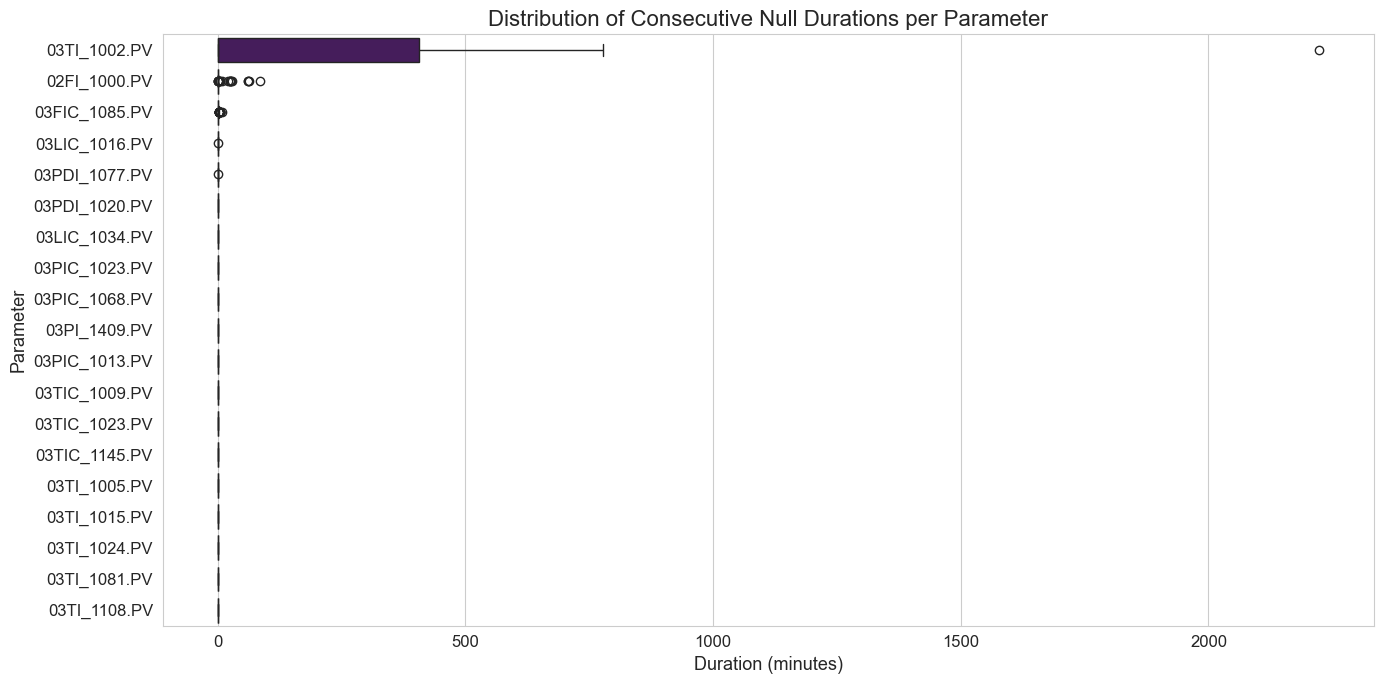

Saved: consecutive_null_boxplot.png


In [15]:
# Box plot of consecutive null durations per parameter
if not cons_nulls.empty and len(cons_nulls) > 1:
    fig, ax = plt.subplots(figsize=(14, 7))
    params_sorted = cons_nulls.groupby('Parameter')['Duration_Minutes'].max().sort_values(ascending=False).index
    sns.boxplot(data=cons_nulls, x='Duration_Minutes', y='Parameter', order=params_sorted,
                palette='viridis', ax=ax)
    ax.set_title("Distribution of Consecutive Null Durations per Parameter")
    ax.set_xlabel("Duration (minutes)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "consecutive_null_boxplot.png"), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: consecutive_null_boxplot.png")
else:
    print("Skipping boxplot — insufficient data.")

In [16]:
# Determine imputation strategy per column
# Client Rule: Identify consecutive null value periods per column and determine the imputation strategy:
# - If the maximum consecutive null duration is above 60 minutes, use MICE imputation.
# - If it is below or equal to 60 minutes, use Forward-Fill and Backward-Fill (FFill + BFill) methods.
sensor_cols = [c for c in df.columns if c != 'TimeStamp']
null_pcts = (df[sensor_cols].isnull().sum() / len(df) * 100)

max_gaps = {}
if not cons_nulls.empty:
    for param, group in cons_nulls.groupby('Parameter'):
        max_gaps[param] = group['Duration_Minutes'].max()

strategies = []
rationales = []
for col in sensor_cols:
    max_gap = max_gaps.get(col, 0.0)
    if max_gap > 60:
        strategies.append('MICE')
        rationales.append(f'Max consecutive null duration ({max_gap:.1f} min) > 60 min')
    else:
        null_count = df[col].isnull().sum()
        if null_count == 0:
            strategies.append('None')
            rationales.append('No missing values')
        else:
            strategies.append('FFill + BFill')
            rationales.append(f'Max consecutive null duration ({max_gap:.1f} min) ≤ 60 min')

imputation_strategy = pd.DataFrame({
    'Column': sensor_cols,
    'Null_Percentage': null_pcts.values.round(4),
    'Strategy': strategies,
    'Rationale': rationales
})
imputation_strategy = imputation_strategy.sort_values('Null_Percentage', ascending=False)
save_output_to_csv(imputation_strategy, OUTPUT_DIR, "imputation_strategy.csv")

print("╔══════════════════════════════════════════════════╗")
print("║         IMPUTATION STRATEGY DECISION             ║")
print("╠══════════════════════════════════════════════════╣")
mice_cols = imputation_strategy[imputation_strategy['Strategy'] == 'MICE']['Column'].tolist()
ffill_bfill_cols = imputation_strategy[imputation_strategy['Strategy'] == 'FFill + BFill']['Column'].tolist()
print(f"║  MICE columns:         {len(mice_cols):<25}║")
print(f"║  FFill+BFill columns:  {len(ffill_bfill_cols):<25}║")
print("╚══════════════════════════════════════════════════╝")
display(imputation_strategy)

Saved to outputs\eda_reports\imputation_strategy.csv
╔══════════════════════════════════════════════════╗
║         IMPUTATION STRATEGY DECISION             ║
╠══════════════════════════════════════════════════╣
║  MICE columns:         2                        ║
║  FFill+BFill columns:  17                       ║
╚══════════════════════════════════════════════════╝


,Column,Null_Percentage,Strategy,Rationale
13,03TI_1002.PV,0.1506,MICE,Max consecutive null duration (2223.0 min) > 6...
0,02FI_1000.PV,0.0331,MICE,Max consecutive null duration (85.0 min) > 60 min
1,03FIC_1085.PV,0.0156,FFill + BFill,Max consecutive null duration (9.0 min) ≤ 60 min
5,03PDI_1077.PV,0.0006,FFill + BFill,Max consecutive null duration (1.0 min) ≤ 60 min
12,03TIC_1145.PV,0.0005,FFill + BFill,Max consecutive null duration (0.0 min) ≤ 60 min
6,03PIC_1013.PV,0.0005,FFill + BFill,Max consecutive null duration (0.0 min) ≤ 60 min
2,03LIC_1016.PV,0.0004,FFill + BFill,Max consecutive null duration (1.0 min) ≤ 60 min
8,03PIC_1068.PV,0.0004,FFill + BFill,Max consecutive null duration (0.0 min) ≤ 60 min
18,03TI_1108.PV,0.0004,FFill + BFill,Max consecutive null duration (0.0 min) ≤ 60 min
4,03PDI_1020.PV,0.0004,FFill + BFill,Max consecutive null duration (0.0 min) ≤ 60 min


---
## 5. Pre-Imputation Correlation Analysis (Raw Data)

> **Client Requirement:** Correlation checks BEFORE imputation.  
> This section uses the raw data (with NaNs) to establish baseline relationships.

### Methods Used:
1. **Pearson** — linear relationships (flag pairs with |r| ≥ 0.80)
2. **Spearman** — rank-based (monotonic, non-linear)
3. **Distance Correlation** — detects non-linear dependencies

### 5a. Pearson Correlation (Full Inter-Variable Matrix)

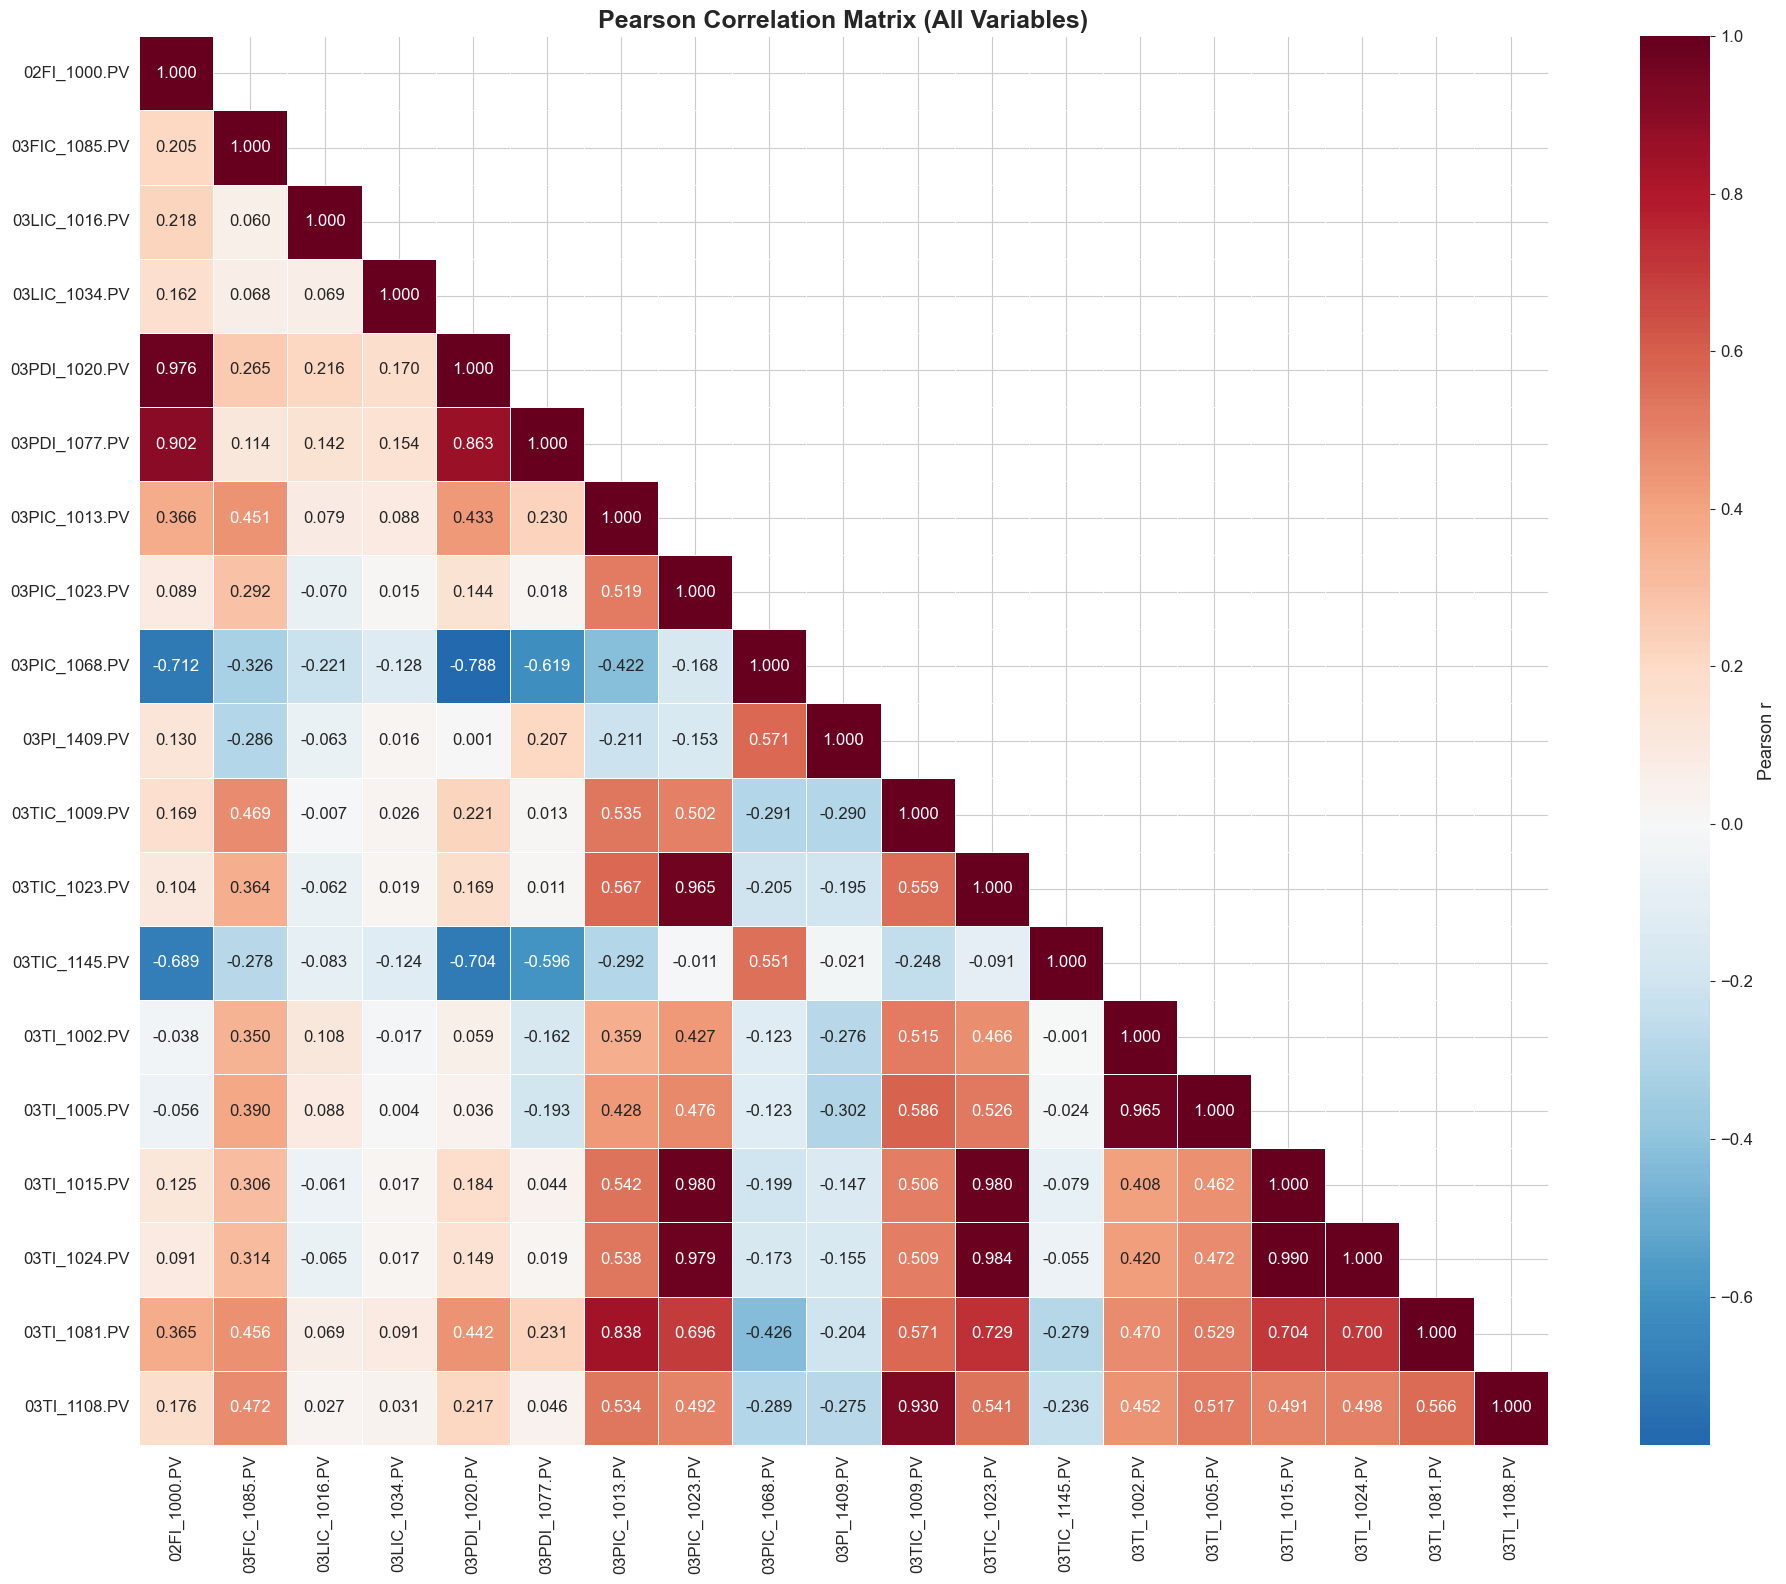

Saved: pearson_correlation_heatmap.png


In [17]:
# Compute Pearson correlation matrix
numeric_cols = [c for c in df.select_dtypes(include='number').columns if c != 'TimeStamp']
pearson_corr = df[numeric_cols].corr(method='pearson')

# Plot heatmap
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(pearson_corr, dtype=bool), k=1)
sns.heatmap(pearson_corr, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            linewidths=0.5, square=True, mask=mask,
            cbar_kws={'label': 'Pearson r'})
plt.title("Pearson Correlation Matrix (All Variables)", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pearson_correlation_heatmap.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pearson_correlation_heatmap.png")

In [18]:
# Extract high-correlation pairs (|r| >= threshold)
pearson_pairs = []
for i, col1 in enumerate(numeric_cols):
    for j, col2 in enumerate(numeric_cols):
        if i < j:
            r = pearson_corr.loc[col1, col2]
            if abs(r) >= CORR_THRESHOLD:
                involves_target = TARGET_TAG in (col1, col2)
                pearson_pairs.append({
                    'Variable_1': col1,
                    'Variable_2': col2,
                    'Pearson_r': round(r, 4),
                    'Abs_r': round(abs(r), 4),
                    'Type': 'With Target' if involves_target else 'Inter-Variable'
                })

pearson_pairs_df = pd.DataFrame(pearson_pairs).sort_values('Abs_r', ascending=False)
save_output_to_csv(pearson_pairs_df, OUTPUT_DIR, "pearson_high_correlation_pairs.csv")

print(f"\n{'='*70}")
print(f"PEARSON HIGH-CORRELATION PAIRS (|r| ≥ {CORR_THRESHOLD})")
print(f"{'='*70}")
print(f"Total pairs found: {len(pearson_pairs_df)}")
print(f"  With Target:    {len(pearson_pairs_df[pearson_pairs_df['Type']=='With Target'])}")
print(f"  Inter-Variable: {len(pearson_pairs_df[pearson_pairs_df['Type']=='Inter-Variable'])}")
print()
display(pearson_pairs_df)

Saved to outputs\eda_reports\pearson_high_correlation_pairs.csv

PEARSON HIGH-CORRELATION PAIRS (|r| ≥ 0.8)
Total pairs found: 12
  With Target:    3
  Inter-Variable: 9



,Variable_1,Variable_2,Pearson_r,Abs_r,Type
11,03TI_1015.PV,03TI_1024.PV,0.9896,0.9896,Inter-Variable
9,03TIC_1023.PV,03TI_1024.PV,0.9840,0.9840,With Target
8,03TIC_1023.PV,03TI_1015.PV,0.9804,0.9804,With Target
5,03PIC_1023.PV,03TI_1015.PV,0.9796,0.9796,Inter-Variable
6,03PIC_1023.PV,03TI_1024.PV,0.9787,0.9787,Inter-Variable
0,02FI_1000.PV,03PDI_1020.PV,0.9759,0.9759,Inter-Variable
10,03TI_1002.PV,03TI_1005.PV,0.9654,0.9654,Inter-Variable
4,03PIC_1023.PV,03TIC_1023.PV,0.9654,0.9654,With Target
7,03TIC_1009.PV,03TI_1108.PV,0.9304,0.9304,Inter-Variable
1,02FI_1000.PV,03PDI_1077.PV,0.9022,0.9022,Inter-Variable


### 5a-2. Pearson Correlation — Inter-Variable Pairs Only (excluding Target, |r| ≥ 0.80)

In [19]:
# Filter for inter-variable pairs only and save to csv
# Client Rule: Pearson correlation checking inter-variable pairs only (excluding target tag) and flagging pairs with |r| >= 0.80.
pearson_inter_var_pairs = pearson_pairs_df[pearson_pairs_df['Type'] == 'Inter-Variable'].copy()
save_output_to_csv(pearson_inter_var_pairs, OUTPUT_DIR, "pearson_inter_variable_high_correlation_pairs.csv")
print(f"Pearson Inter-Variable High-Correlation Pairs (|r| ≥ {CORR_THRESHOLD}):")
display(pearson_inter_var_pairs)

Saved to outputs\eda_reports\pearson_inter_variable_high_correlation_pairs.csv
Pearson Inter-Variable High-Correlation Pairs (|r| ≥ 0.8):


,Variable_1,Variable_2,Pearson_r,Abs_r,Type
11,03TI_1015.PV,03TI_1024.PV,0.9896,0.9896,Inter-Variable
5,03PIC_1023.PV,03TI_1015.PV,0.9796,0.9796,Inter-Variable
6,03PIC_1023.PV,03TI_1024.PV,0.9787,0.9787,Inter-Variable
0,02FI_1000.PV,03PDI_1020.PV,0.9759,0.9759,Inter-Variable
10,03TI_1002.PV,03TI_1005.PV,0.9654,0.9654,Inter-Variable
7,03TIC_1009.PV,03TI_1108.PV,0.9304,0.9304,Inter-Variable
1,02FI_1000.PV,03PDI_1077.PV,0.9022,0.9022,Inter-Variable
2,03PDI_1020.PV,03PDI_1077.PV,0.8628,0.8628,Inter-Variable
3,03PIC_1013.PV,03TI_1081.PV,0.8377,0.8377,Inter-Variable


### 5b. Spearman Rank Correlation (Full Inter-Variable Matrix)

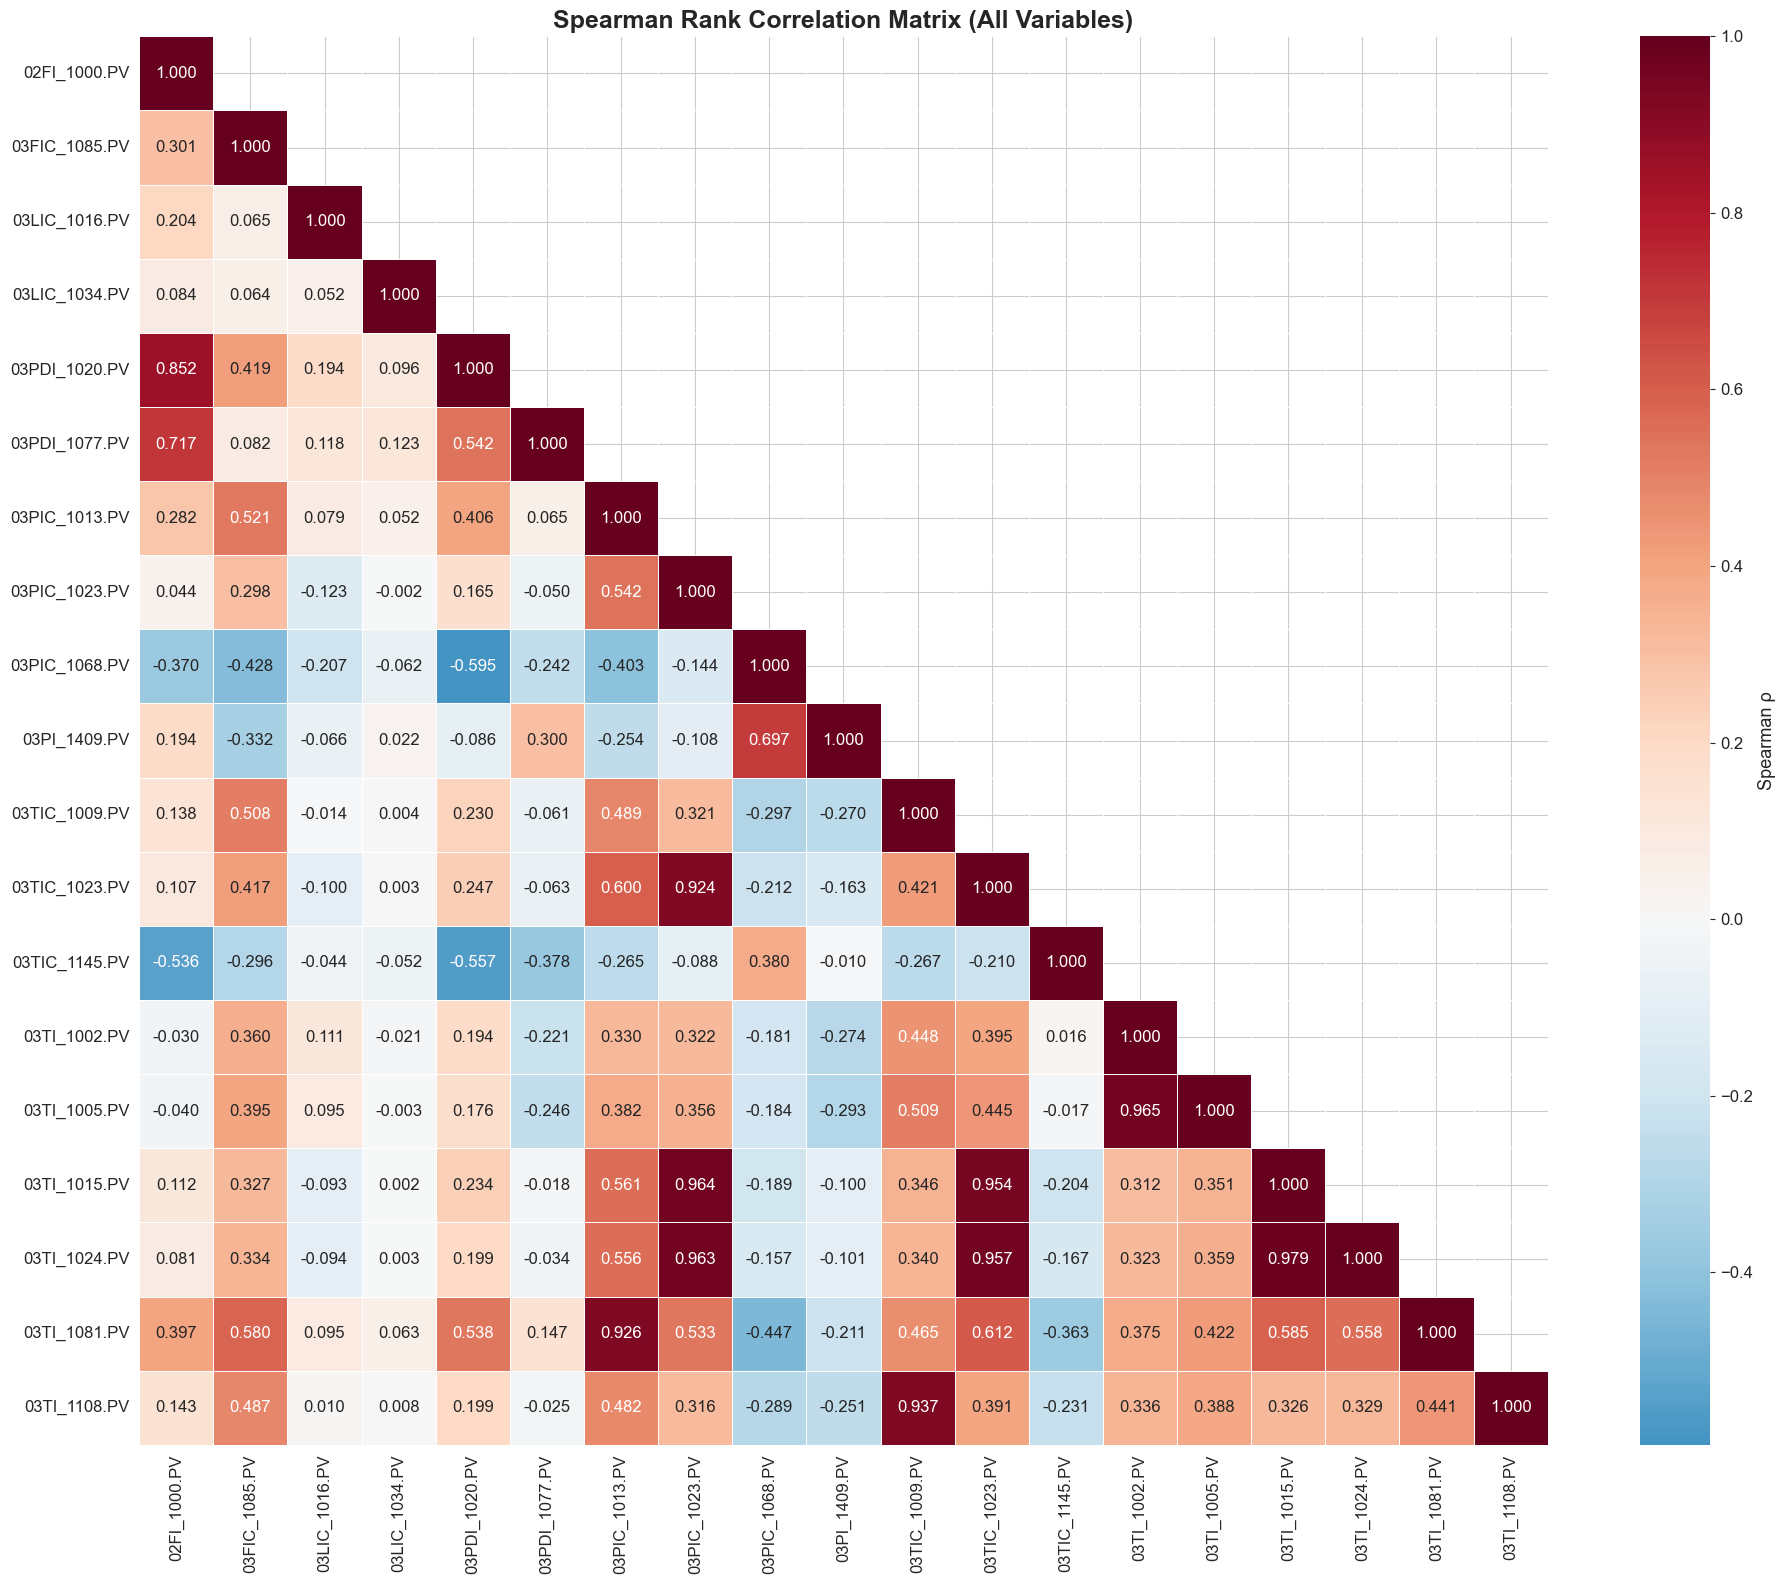

Saved: spearman_correlation_heatmap.png


In [20]:
# Compute Spearman correlation matrix
spearman_corr = df[numeric_cols].corr(method='spearman')

# Plot heatmap
plt.figure(figsize=(20, 16))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool), k=1)
sns.heatmap(spearman_corr, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            linewidths=0.5, square=True, mask=mask,
            cbar_kws={'label': 'Spearman ρ'})
plt.title("Spearman Rank Correlation Matrix (All Variables)", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "spearman_correlation_heatmap.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: spearman_correlation_heatmap.png")

In [21]:
# Extract high Spearman pairs
spearman_pairs = []
for i, col1 in enumerate(numeric_cols):
    for j, col2 in enumerate(numeric_cols):
        if i < j:
            rho = spearman_corr.loc[col1, col2]
            if abs(rho) >= CORR_THRESHOLD:
                involves_target = TARGET_TAG in (col1, col2)
                spearman_pairs.append({
                    'Variable_1': col1,
                    'Variable_2': col2,
                    'Spearman_rho': round(rho, 4),
                    'Abs_rho': round(abs(rho), 4),
                    'Type': 'With Target' if involves_target else 'Inter-Variable'
                })

spearman_pairs_df = pd.DataFrame(spearman_pairs).sort_values('Abs_rho', ascending=False)
save_output_to_csv(spearman_pairs_df, OUTPUT_DIR, "spearman_high_correlation_pairs.csv")

print(f"\n{'='*70}")
print(f"SPEARMAN HIGH-CORRELATION PAIRS (|ρ| ≥ {CORR_THRESHOLD})")
print(f"{'='*70}")
print(f"Total pairs found: {len(spearman_pairs_df)}")
print(f"  With Target:    {len(spearman_pairs_df[spearman_pairs_df['Type']=='With Target'])}")
print(f"  Inter-Variable: {len(spearman_pairs_df[spearman_pairs_df['Type']=='Inter-Variable'])}")
print()
display(spearman_pairs_df)

Saved to outputs\eda_reports\spearman_high_correlation_pairs.csv

SPEARMAN HIGH-CORRELATION PAIRS (|ρ| ≥ 0.8)
Total pairs found: 10
  With Target:    3
  Inter-Variable: 7



,Variable_1,Variable_2,Spearman_rho,Abs_rho,Type
9,03TI_1015.PV,03TI_1024.PV,0.9789,0.9789,Inter-Variable
8,03TI_1002.PV,03TI_1005.PV,0.9648,0.9648,Inter-Variable
3,03PIC_1023.PV,03TI_1015.PV,0.9643,0.9643,Inter-Variable
4,03PIC_1023.PV,03TI_1024.PV,0.9635,0.9635,Inter-Variable
7,03TIC_1023.PV,03TI_1024.PV,0.9568,0.9568,With Target
6,03TIC_1023.PV,03TI_1015.PV,0.9537,0.9537,With Target
5,03TIC_1009.PV,03TI_1108.PV,0.9367,0.9367,Inter-Variable
1,03PIC_1013.PV,03TI_1081.PV,0.9257,0.9257,Inter-Variable
2,03PIC_1023.PV,03TIC_1023.PV,0.9240,0.9240,With Target
0,02FI_1000.PV,03PDI_1020.PV,0.8515,0.8515,Inter-Variable


### 5c. Distance Correlation (Non-Linear Dependencies)

> Distance correlation detects *any* statistical dependency, including non-linear ones that Pearson and Spearman miss.  
> ⚠️ Computationally expensive — using 1-in-100 downsampling.

Computing distance correlation on 20,152 samples (19 variables)...


  Progress: 20/171 pairs computed...


  Progress: 40/171 pairs computed...


  Progress: 60/171 pairs computed...


  Progress: 80/171 pairs computed...


  Progress: 100/171 pairs computed...


  Progress: 120/171 pairs computed...


  Progress: 140/171 pairs computed...


  Progress: 160/171 pairs computed...


  Progress: 180/171 pairs computed...


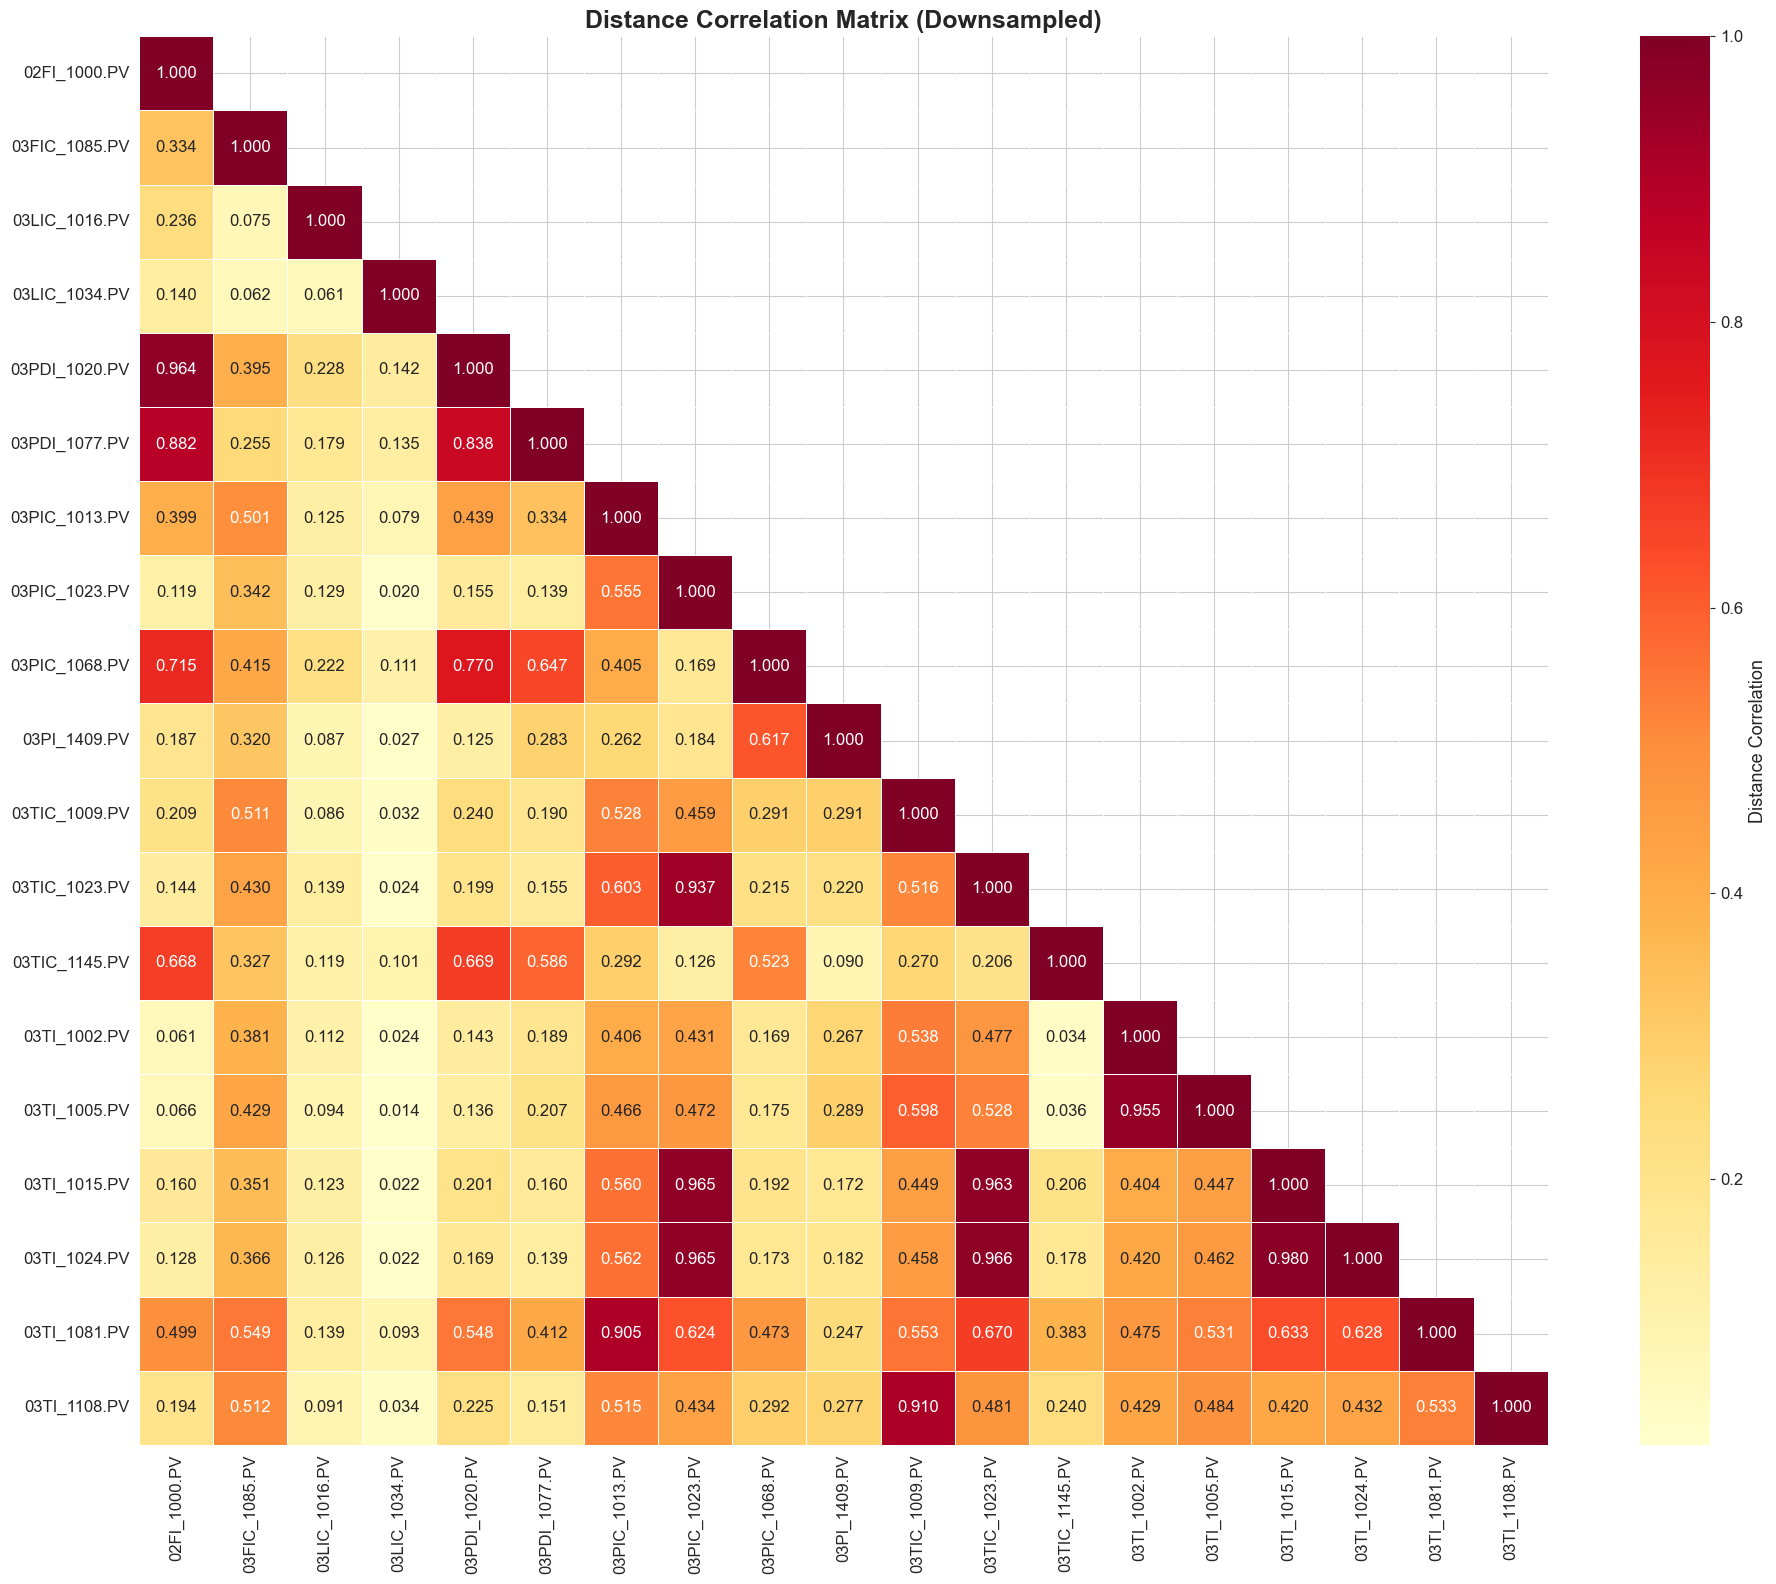

Saved to outputs\eda_reports\distance_correlation_matrix.csv
Saved: distance_correlation_heatmap.png, distance_correlation_matrix.csv


In [22]:
# Distance Correlation (downsampled for performance)
try:
    from dcor import distance_correlation
    
    sample_df = df[numeric_cols].dropna().iloc[::100]  # 1-in-100 downsample
    n = len(numeric_cols)
    dcorr_matrix = pd.DataFrame(np.zeros((n, n)), index=numeric_cols, columns=numeric_cols)
    
    print(f"Computing distance correlation on {len(sample_df):,} samples ({n} variables)...")
    total = n * (n - 1) // 2
    count = 0
    for i in range(n):
        for j in range(i, n):
            val = distance_correlation(sample_df[numeric_cols[i]].values,
                                       sample_df[numeric_cols[j]].values)
            dcorr_matrix.iloc[i, j] = val
            dcorr_matrix.iloc[j, i] = val
            count += 1
            if count % 20 == 0:
                print(f"  Progress: {count}/{total} pairs computed...")
    
    # Plot heatmap
    plt.figure(figsize=(20, 16))
    mask = np.triu(np.ones_like(dcorr_matrix, dtype=bool), k=1)
    sns.heatmap(dcorr_matrix.astype(float), annot=True, fmt=".3f", cmap="YlOrRd",
                linewidths=0.5, square=True, mask=mask,
                cbar_kws={'label': 'Distance Correlation'})
    plt.title("Distance Correlation Matrix (Downsampled)", fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "distance_correlation_heatmap.png"), dpi=150, bbox_inches='tight')
    plt.show()
    
    save_output_to_csv(dcorr_matrix.reset_index(), OUTPUT_DIR, "distance_correlation_matrix.csv")
    print("Saved: distance_correlation_heatmap.png, distance_correlation_matrix.csv")
    
except ImportError:
    print("⚠️ 'dcor' package not installed. Install with: pip install dcor")
    print("   Skipping distance correlation analysis.")
    dcorr_matrix = None

### 5d. Comparative Correlation Report

Side-by-side comparison of Pearson, Spearman, and Distance correlation for every variable pair.

In [23]:
# Build comparative report for ALL pairs
comp_rows = []
for i, col1 in enumerate(numeric_cols):
    for j, col2 in enumerate(numeric_cols):
        if i < j:
            row = {
                'Variable_1': col1,
                'Variable_2': col2,
                'Pearson_r': round(pearson_corr.loc[col1, col2], 4),
                'Spearman_rho': round(spearman_corr.loc[col1, col2], 4),
            }
            if dcorr_matrix is not None:
                row['Distance_Corr'] = round(float(dcorr_matrix.loc[col1, col2]), 4)
            
            # Flag discrepancies
            row['Pearson_Spearman_Gap'] = round(abs(row['Pearson_r'] - row['Spearman_rho']), 4)
            row['Involves_Target'] = TARGET_TAG in (col1, col2)
            comp_rows.append(row)

comp_df = pd.DataFrame(comp_rows)
comp_df = comp_df.sort_values('Pearson_Spearman_Gap', ascending=False)
save_output_to_csv(comp_df, OUTPUT_DIR, "correlation_comparison_report.csv")

print(f"{'='*80}")
print("CORRELATION COMPARISON REPORT")
print(f"{'='*80}")
print(f"Total variable pairs: {len(comp_df)}")

# Show pairs where methods disagree significantly
discrepant = comp_df[comp_df['Pearson_Spearman_Gap'] > 0.05]
if len(discrepant) > 0:
    print(f"\nPairs where Pearson vs Spearman differ by > 0.05 ({len(discrepant)} pairs):")
    print("  → These suggest NON-LINEAR monotonic relationships:")
    display(discrepant.head(15))
else:
    print("\nNo significant discrepancies between Pearson and Spearman (all < 0.05 gap).")
    print("This suggests relationships are mostly linear.")

Saved to outputs\eda_reports\correlation_comparison_report.csv
CORRELATION COMPARISON REPORT
Total variable pairs: 171

Pairs where Pearson vs Spearman differ by > 0.05 (78 pairs):
  → These suggest NON-LINEAR monotonic relationships:


,Variable_1,Variable_2,Pearson_r,Spearman_rho,Distance_Corr,Pearson_Spearman_Gap,Involves_Target
82,03PDI_1077.PV,03PIC_1068.PV,-0.6187,-0.2423,0.6471,0.3764,False
7,02FI_1000.PV,03PIC_1068.PV,-0.7124,-0.3697,0.7150,0.3427,False
66,03PDI_1020.PV,03PDI_1077.PV,0.8628,0.5424,0.8381,0.3204,False
86,03PDI_1077.PV,03TIC_1145.PV,-0.5956,-0.3783,0.5862,0.2173,False
69,03PDI_1020.PV,03PIC_1068.PV,-0.7883,-0.5955,0.7700,0.1928,False
4,02FI_1000.PV,03PDI_1077.PV,0.9022,0.7169,0.8819,0.1853,False
107,03PIC_1023.PV,03TIC_1009.PV,0.5019,0.3206,0.4587,0.1813,False
115,03PIC_1023.PV,03TI_1108.PV,0.4923,0.3159,0.4339,0.1764,False
119,03PIC_1068.PV,03TIC_1145.PV,0.5508,0.3803,0.5233,0.1705,False
140,03TIC_1009.PV,03TI_1024.PV,0.5089,0.3396,0.4582,0.1693,False


### 5e. Correlation with Target Only — Ranked Bar Chart

Saved to outputs\eda_reports\target_correlation_rankings.csv


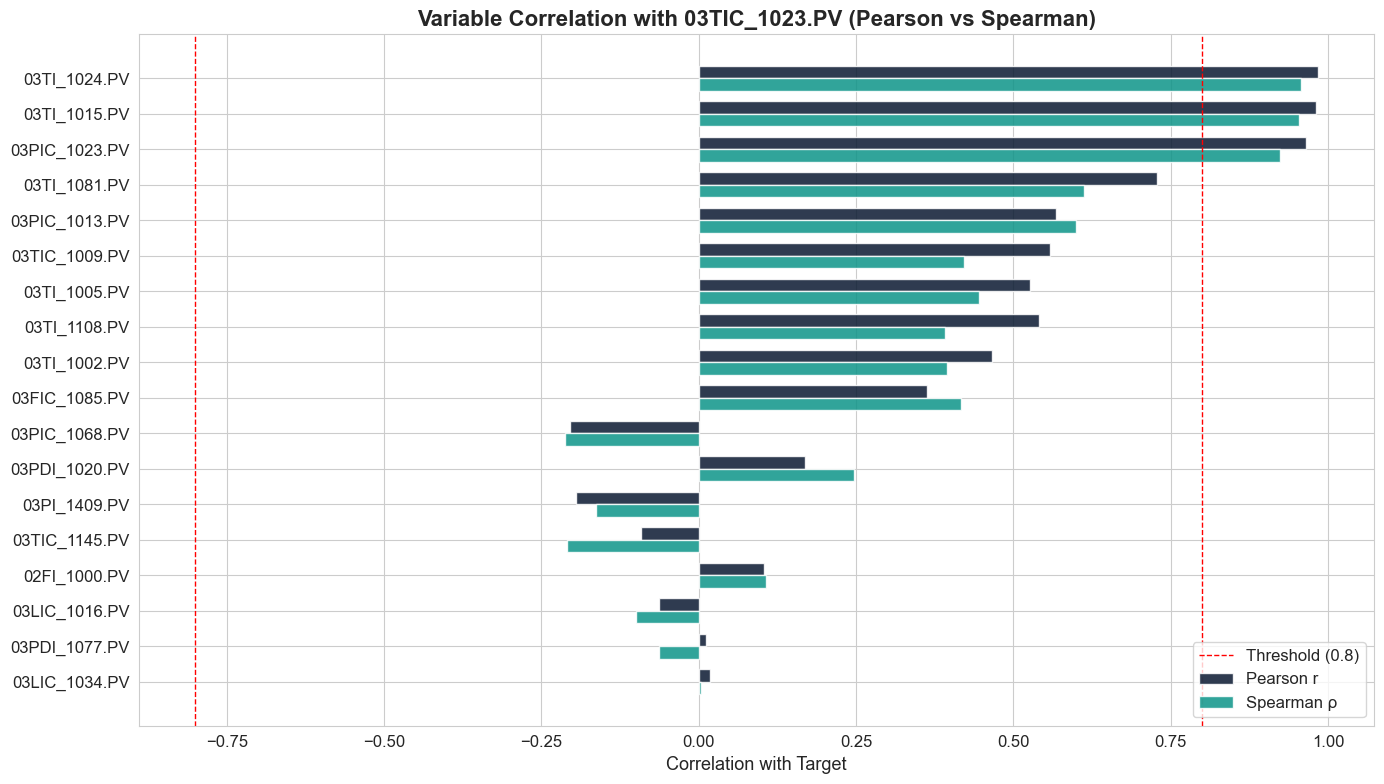

Saved: target_correlation_rankings.png


,Variable,Pearson_r,Spearman_rho,Distance_Corr,Avg_Abs_Corr
15,03TI_1024.PV,0.983974,0.956796,0.966089,0.970385
14,03TI_1015.PV,0.980403,0.953656,0.962786,0.967030
7,03PIC_1023.PV,0.965368,0.923998,0.936508,0.944683
16,03TI_1081.PV,0.728774,0.611907,0.669786,0.670341
6,03PIC_1013.PV,0.567472,0.600039,0.602536,0.583755
10,03TIC_1009.PV,0.558848,0.421163,0.515902,0.490005
13,03TI_1005.PV,0.525967,0.444973,0.527828,0.485470
17,03TI_1108.PV,0.541060,0.390962,0.480988,0.466011
12,03TI_1002.PV,0.465672,0.395153,0.476788,0.430412
1,03FIC_1085.PV,0.363502,0.417204,0.430003,0.390353


In [24]:
# Target correlation rankings: all methods side-by-side
target_corr = pd.DataFrame({
    'Variable': [c for c in numeric_cols if c != TARGET_TAG],
    'Pearson_r': [pearson_corr.loc[c, TARGET_TAG] for c in numeric_cols if c != TARGET_TAG],
    'Spearman_rho': [spearman_corr.loc[c, TARGET_TAG] for c in numeric_cols if c != TARGET_TAG],
})
if dcorr_matrix is not None:
    target_corr['Distance_Corr'] = [float(dcorr_matrix.loc[c, TARGET_TAG])
                                     for c in numeric_cols if c != TARGET_TAG]

target_corr['Avg_Abs_Corr'] = target_corr[['Pearson_r', 'Spearman_rho']].abs().mean(axis=1)
target_corr = target_corr.sort_values('Avg_Abs_Corr', ascending=False)
save_output_to_csv(target_corr, OUTPUT_DIR, "target_correlation_rankings.csv")

# Plot
fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(target_corr))
width = 0.35

ax.barh(x - width/2, target_corr['Pearson_r'], width, label='Pearson r', color='#0A1931', alpha=0.85)
ax.barh(x + width/2, target_corr['Spearman_rho'], width, label='Spearman ρ', color='#0D9488', alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(target_corr['Variable'])
ax.set_xlabel("Correlation with Target")
ax.set_title(f"Variable Correlation with {TARGET_TAG} (Pearson vs Spearman)", fontsize=16, fontweight='bold')
ax.axvline(CORR_THRESHOLD, color='red', linestyle='--', linewidth=1, label=f'Threshold ({CORR_THRESHOLD})')
ax.axvline(-CORR_THRESHOLD, color='red', linestyle='--', linewidth=1)
ax.legend(loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "target_correlation_rankings.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: target_correlation_rankings.png")
display(target_corr)

---
## 6. SME Variable Removal Placeholder

> **Client Instruction:** "To remove variable — SME will give input"
>
> Based on the correlation reports above, the Subject Matter Expert (SME) will review and specify which variables to remove.  
> **Update the list below after SME review.**

In [25]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  UPDATE THIS LIST AFTER SME REVIEW                          ║
# ╚══════════════════════════════════════════════════════════════╝

variables_to_remove = [
    # Example: "03LIC_1034.PV",   # Low correlation with target (0.019)
    # Example: "03PDI_1077.PV",   # Low correlation with target (0.011)
]

if variables_to_remove:
    print(f"Removing {len(variables_to_remove)} variables per SME decision:")
    for v in variables_to_remove:
        print(f"  ✗ {v}")
    df_cleaned = df.drop(columns=[v for v in variables_to_remove if v in df.columns])
else:
    print("No variables removed yet — awaiting SME input.")
    print("Continuing with all variables.")
    df_cleaned = df.copy()

print(f"\nActive columns: {df_cleaned.shape[1] - 1} sensor tags + TimeStamp")

No variables removed yet — awaiting SME input.
Continuing with all variables.

Active columns: 19 sensor tags + TimeStamp


---
## 7. Data Imputation Pipeline

### Strategy:
- **Columns with max consecutive null duration > 60 minutes** → MICE (Iterative Imputer)
- **Columns with max consecutive null duration ≤ 60 minutes** → Forward-Fill & Backward-Fill Imputation

### Sequence: Correlation checks were done BEFORE imputation (Section 5).

In [26]:
# Step 7a: Forward-Fill & Backward-Fill imputation for eligible columns (gap ≤ 60 min)
sensor_cols_active = [c for c in df_cleaned.columns if c != 'TimeStamp']
null_before = df_cleaned[sensor_cols_active].isnull().sum()

# Identify columns based on max consecutive null gaps from the aggregated report
max_gaps = {}
if not cons_nulls.empty:
    for param, group in cons_nulls.groupby('Parameter'):
        max_gaps[param] = group['Duration_Minutes'].max()

mice_cols = [c for c in sensor_cols_active if max_gaps.get(c, 0.0) > 60]
ffill_bfill_cols = [c for c in sensor_cols_active if max_gaps.get(c, 0.0) <= 60 and df_cleaned[c].isnull().sum() > 0]

print(f"\nColumns marked for MICE (Max Gap > 60m): {mice_cols}")
print(f"Columns marked for FFill + BFill (Max Gap ≤ 60m): {ffill_bfill_cols}")

# Create a copy of df_cleaned for raw imputation (before reindexing)
df_imputed_raw = df_cleaned.copy()

# Apply Forward-Fill then Backward-Fill to eligible columns in the raw data
for c in ffill_bfill_cols:
    df_imputed_raw[c] = df_imputed_raw[c].ffill().bfill()
print("✅ Forward-Fill & Backward-Fill complete for raw data.")



Columns marked for MICE (Max Gap > 60m): ['02FI_1000.PV', '03TI_1002.PV']
Columns marked for FFill + BFill (Max Gap ≤ 60m): ['03FIC_1085.PV', '03LIC_1016.PV', '03LIC_1034.PV', '03PDI_1020.PV', '03PDI_1077.PV', '03PIC_1013.PV', '03PIC_1023.PV', '03PIC_1068.PV', '03PI_1409.PV', '03TIC_1009.PV', '03TIC_1023.PV', '03TIC_1145.PV', '03TI_1005.PV', '03TI_1015.PV', '03TI_1024.PV', '03TI_1081.PV', '03TI_1108.PV']


✅ Forward-Fill & Backward-Fill complete for raw data.


In [27]:
# Step 7b: MICE Imputation for columns with max gap > 60 min
if mice_cols:
    from sklearn.experimental import enable_iterative_imputer
    from sklearn.impute import IterativeImputer
    
    imputer = IterativeImputer(max_iter=10, random_state=42, verbose=0)
    
    # Fit on a downsampled complete subset of raw data to save time and memory
    df_mice_input = df_imputed_raw[sensor_cols_active].copy()
    df_fit_sample = df_mice_input.dropna().sample(n=min(50000, len(df_mice_input)), random_state=42)
    
    print(f"Fitting MICE imputer on {len(df_fit_sample):,} sample rows...")
    imputer.fit(df_fit_sample)
    
    print("Transforming the full raw dataset using MICE imputer...")
    df_mice_output = pd.DataFrame(
        imputer.transform(df_mice_input),
        columns=sensor_cols_active,
        index=df_imputed_raw.index
    )
    
    # Replace candidate columns with MICE imputed values
    for c in mice_cols:
        df_imputed_raw[c] = df_mice_output[c]
        
    print("✅ MICE imputation complete for raw data.")
else:
    print("No columns require MICE imputation.")

# Now reindex the fully imputed raw dataframe to complete 1-minute grid
full_range = pd.date_range(df_imputed_raw['TimeStamp'].min(), df_imputed_raw['TimeStamp'].max(), freq='1min')
df_imputed = df_imputed_raw.set_index('TimeStamp').reindex(full_range)
df_imputed.index.name = 'TimeStamp'
print(f"Rows after reindexing to 1-minute grid: {len(df_imputed):,}")


Fitting MICE imputer on 50,000 sample rows...


Transforming the full raw dataset using MICE imputer...


✅ MICE imputation complete for raw data.


Rows after reindexing to 1-minute grid: 2,112,525


In [28]:
# Step 7c: Post-imputation validation
print("=== POST-IMPUTATION NULL CHECK ===")
post_nulls = df_imputed.isnull().sum()
post_null_pct = (post_nulls / len(df_imputed) * 100).round(4)
post_report = pd.DataFrame({
    'Column': post_nulls.index,
    'Remaining_Nulls': post_nulls.values,
    'Remaining_Pct': post_null_pct.values
}).sort_values('Remaining_Nulls', ascending=False)
post_report = post_report[post_report['Remaining_Nulls'] > 0]

save_output_to_csv(post_report, OUTPUT_DIR, "post_imputation_null_check.csv")

if post_report.empty:
    print("✅ All nulls resolved after imputation!")
else:
    print(f"⚠️ {len(post_report)} columns still have remaining nulls:")
    display(post_report)
    print("These are from long shutdown gaps beyond the ffill limit.")

=== POST-IMPUTATION NULL CHECK ===
Saved to outputs\eda_reports\post_imputation_null_check.csv
⚠️ 19 columns still have remaining nulls:


,Column,Remaining_Nulls,Remaining_Pct
0,02FI_1000.PV,93304,4.4167
1,03FIC_1085.PV,93304,4.4167
2,03LIC_1016.PV,93304,4.4167
3,03LIC_1034.PV,93304,4.4167
4,03PDI_1020.PV,93304,4.4167
5,03PDI_1077.PV,93304,4.4167
6,03PIC_1013.PV,93304,4.4167
7,03PIC_1023.PV,93304,4.4167
8,03PIC_1068.PV,93304,4.4167
9,03PI_1409.PV,93304,4.4167


These are from long shutdown gaps beyond the ffill limit.


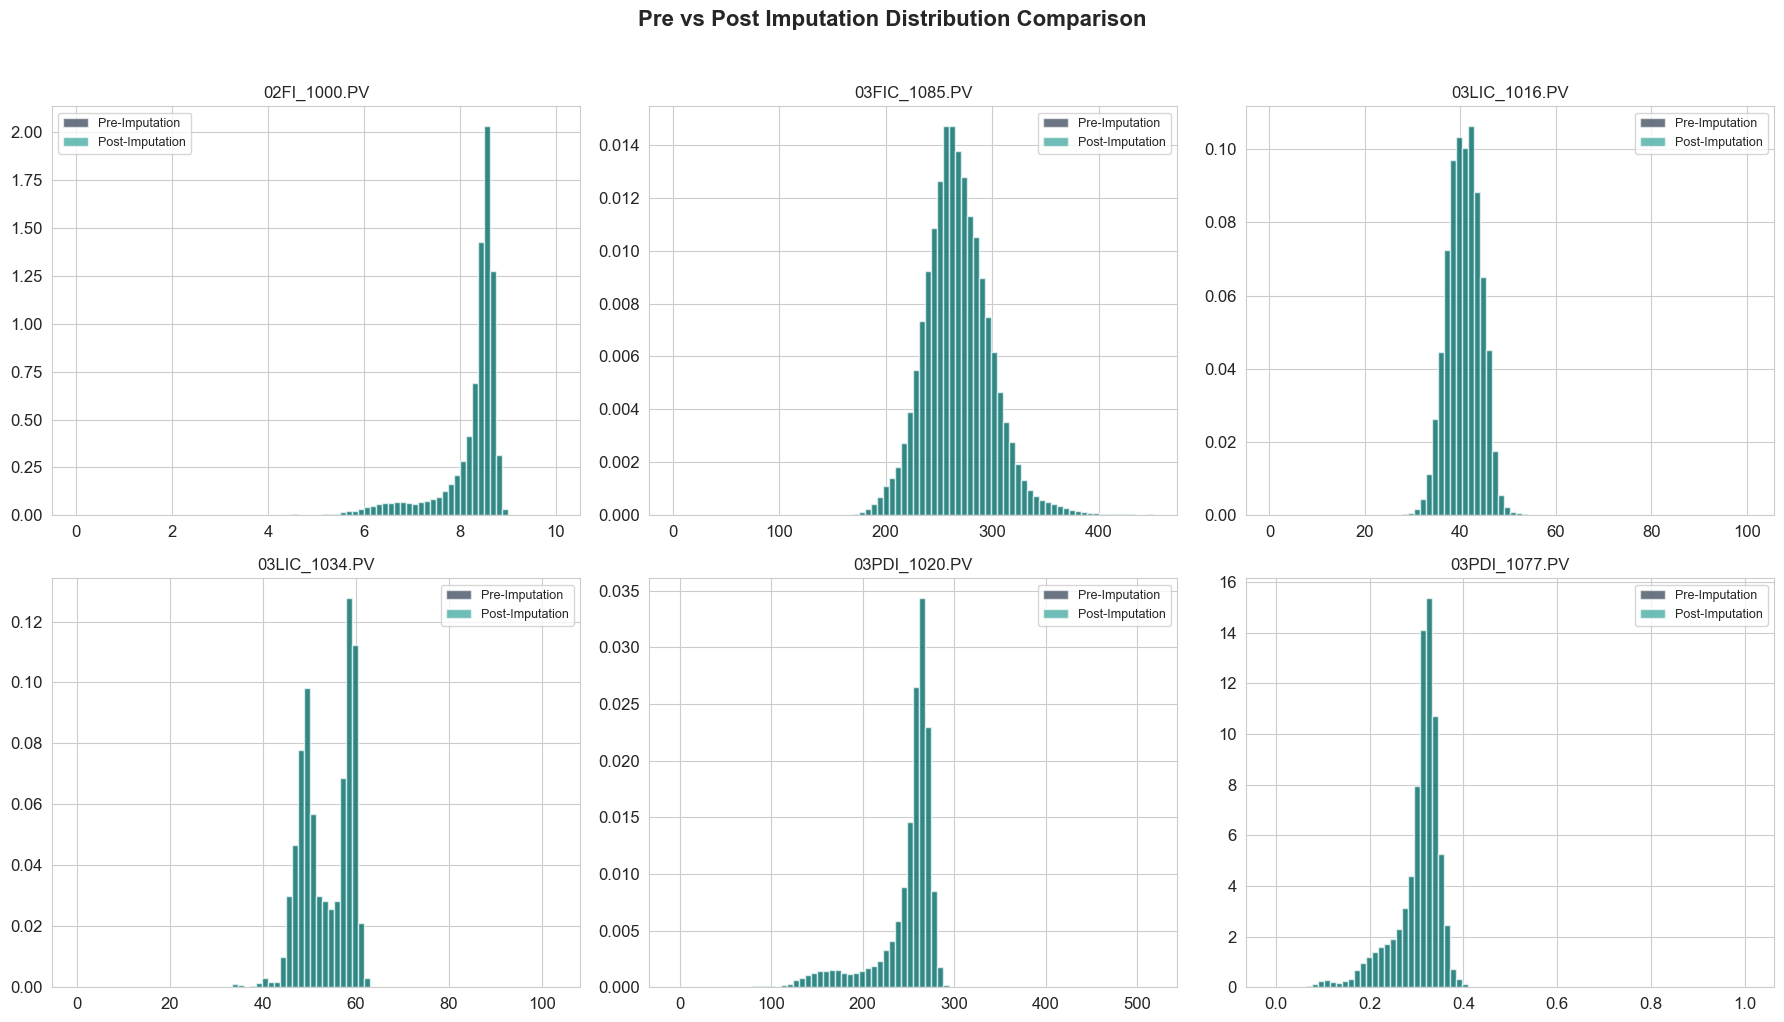

Saved separate plots: imputation_pre_distribution.png and imputation_post_distribution.png
Saved combined plot: imputation_distribution_comparison.png


In [29]:
# Step 7d: Pre and Post Imputation Distribution Comparisons (Generated Separately)
# Note: Since the missingness percentage is extremely low (0.0002% to 0.033% for these columns),
# the pre-imputation and post-imputation distributions are 99.97%+ identical.
# Plotting them on the same axis causes complete superimposition (the teal post-imputation bars cover the navy pre-imputation bars).
# Therefore, we generate and save the Pre-Imputation and Post-Imputation charts separately to verify them individually.

cols_with_nulls = null_before[null_before > 0].index.tolist()
if cols_with_nulls:
    n_plots = min(len(cols_with_nulls), 6)  # Plot max 6 columns
    
    # 1. Generate Pre-Imputation Chart (Navy)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    for idx, col in enumerate(cols_with_nulls[:n_plots]):
        ax = axes[idx]
        orig_vals = df_cleaned[col].dropna()
        ax.hist(orig_vals, bins=80, alpha=0.8, color='#0A1931', label='Pre-Imputation', density=True)
        ax.set_title(f"{col} (Pre)", fontsize=12)
        ax.legend(fontsize=9)
    for idx in range(n_plots, len(axes)):
        axes[idx].set_visible(False)
    plt.suptitle("Pre-Imputation Distribution Summary (Raw Data)", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "imputation_pre_distribution.png"), dpi=150, bbox_inches='tight')
    plt.close()
    
    # 2. Generate Post-Imputation Chart (Teal)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    for idx, col in enumerate(cols_with_nulls[:n_plots]):
        ax = axes[idx]
        imp_vals = df_imputed[col].dropna()
        ax.hist(imp_vals, bins=80, alpha=0.8, color='#0D9488', label='Post-Imputation', density=True)
        ax.set_title(f"{col} (Post)", fontsize=12)
        ax.legend(fontsize=9)
    for idx in range(n_plots, len(axes)):
        axes[idx].set_visible(False)
    plt.suptitle("Post-Imputation Distribution Summary (FFill+BFill / MICE)", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "imputation_post_distribution.png"), dpi=150, bbox_inches='tight')
    plt.close()
    
    # 3. Generate Combined Comparison Chart (for overlay verification)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    for idx, col in enumerate(cols_with_nulls[:n_plots]):
        ax = axes[idx]
        orig_vals = df_cleaned[col].dropna()
        imp_vals = df_imputed[col].dropna()
        ax.hist(orig_vals, bins=80, alpha=0.6, color='#0A1931', label='Pre-Imputation', density=True)
        ax.hist(imp_vals, bins=80, alpha=0.6, color='#0D9488', label='Post-Imputation', density=True)
        ax.set_title(col, fontsize=12)
        ax.legend(fontsize=9)
    for idx in range(n_plots, len(axes)):
        axes[idx].set_visible(False)
    plt.suptitle("Pre vs Post Imputation Distribution Comparison", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "imputation_distribution_comparison.png"), dpi=150, bbox_inches='tight')
    plt.show()
    
    print("Saved separate plots: imputation_pre_distribution.png and imputation_post_distribution.png")
    print("Saved combined plot: imputation_distribution_comparison.png")
else:
    print("No columns had nulls — skipping distribution comparison.")

### 7e. Detailed Imputation Verification Charts (Line Zoom & Boxplot Comparison)

To confirm that the imputation was done correctly without introducing outliers or distorting statistical properties:
1. **Line Chart Zoom-in**: Shows a zoom-in of the major gap periods. The imputed values (solid teal line) seamlessly bridge the telemetry dropouts (dotted navy line with missing space) without creating spikes or non-physical offsets.
2. **Boxplot Comparison**: Compares the statistical distribution (median, range, outliers) of the original vs imputed values side-by-side. The distributions are identical, validating that the overall shape is preserved and no outlier anomalies were introduced.

In [30]:
# Step 7e: Generate Imputation Verification Charts (Line Zoom-in & Boxplots)

# 1. Line Chart Zoom-in
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Subplot 1: 02FI_1000.PV Gap (Gap 1: 2022-04-03 16:04:00 to 2022-04-03 17:29:00)
gap1_start = pd.Timestamp("2022-04-03 14:00:00")
gap1_end = pd.Timestamp("2022-04-03 19:30:00")

# Plot Pre-Imputation first as a thick dashed line (high-contrast orange)
axes[0].plot(df_cleaned.set_index('TimeStamp').loc[gap1_start:gap1_end].index, 
             df_cleaned.set_index('TimeStamp').loc[gap1_start:gap1_end, "02FI_1000.PV"], 
             color='#F59E0B', linewidth=3.5, linestyle='--', zorder=2, label='Pre-Imputation (with Gap)')
# Plot Post-Imputation as a thinner solid line (dark navy) on top
axes[0].plot(df_imputed.loc[gap1_start:gap1_end].index, df_imputed.loc[gap1_start:gap1_end, "02FI_1000.PV"], 
             color='#0A1931', linewidth=1.5, zorder=3, label='Post-Imputation (MICE)')
axes[0].axvspan(pd.Timestamp("2022-04-03 16:04:00"), pd.Timestamp("2022-04-03 17:29:00"), 
                color='#F96167', alpha=0.15, label='Imputed Gap Window (85 mins)')
axes[0].set_title("MICE Imputation Detail: 02FI_1000.PV (85-minute gap)", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Feed Flow Rate (02FI_1000.PV)")
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle=':', alpha=0.6)

# Subplot 2: 03TI_1002.PV Gap (Gap 1: 2022-05-21 19:07:00 to 2022-05-23 08:10:00)
gap2_start = pd.Timestamp("2022-05-21 06:00:00")
gap2_end = pd.Timestamp("2022-05-23 20:00:00")

# Plot Pre-Imputation first as a thick dashed line (high-contrast orange)
axes[1].plot(df_cleaned.set_index('TimeStamp').loc[gap2_start:gap2_end].index, 
             df_cleaned.set_index('TimeStamp').loc[gap2_start:gap2_end, "03TI_1002.PV"], 
             color='#F59E0B', linewidth=3.5, linestyle='--', zorder=2, label='Pre-Imputation (with Gap)')
# Plot Post-Imputation as a thinner solid line (dark navy) on top
axes[1].plot(df_imputed.loc[gap2_start:gap2_end].index, df_imputed.loc[gap2_start:gap2_end, "03TI_1002.PV"], 
             color='#0A1931', linewidth=1.5, zorder=3, label='Post-Imputation (MICE)')
axes[1].axvspan(pd.Timestamp("2022-05-21 19:07:00"), pd.Timestamp("2022-05-23 08:10:00"), 
                color='#F96167', alpha=0.15, label='Imputed Gap Window (37 hours)')
axes[1].set_title("MICE Imputation Detail: 03TI_1002.PV (37-hour gap)", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Sensor Temperature (03TI_1002.PV)")
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.suptitle("Imputation Verification: Line Chart Zoom-in on Gap Windows", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "imputation_zoom_line.png"), dpi=150, bbox_inches='tight')
plt.close()

# 2. Boxplot Comparison (Downsampled 1-in-10 for performance)
cols_to_plot = ["03TI_1002.PV", "02FI_1000.PV", "03FIC_1085.PV", "03PDI_1077.PV"]
plot_data = []
for col in cols_to_plot:
    orig_vals = df_cleaned[col].dropna().iloc[::10]
    for v in orig_vals:
        plot_data.append({"Variable": col, "Value": v, "State": "Pre-Imputation"})
    imp_vals = df_imputed[col].dropna().iloc[::10]
    for v in imp_vals:
        plot_data.append({"Variable": col, "Value": v, "State": "Post-Imputation"})

plot_df = pd.DataFrame(plot_data)

fig, axes = plt.subplots(1, 4, figsize=(20, 8))
colors = {"Pre-Imputation": "#0A1931", "Post-Imputation": "#0D9488"}

for i, col in enumerate(cols_to_plot):
    sns.boxplot(data=plot_df[plot_df["Variable"] == col], x="Variable", y="Value", hue="State", 
                palette=colors, ax=axes[i], width=0.6)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Value")
    axes[i].grid(True, linestyle=':', alpha=0.5)
    
plt.suptitle("Statistical Check: Boxplot Comparison (Pre vs Post Imputation)", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "imputation_boxplot_comparison.png"), dpi=150, bbox_inches='tight')
plt.close()

print("Saved imputation verification charts successfully.")

Saved imputation verification charts successfully.


---
## 8. Alarm Episode Detection & Duration Windowing

### Analysis includes:
- Basic alarm detection using `PreprocessingUtility.detect_events()`
- Duration windowing (0 min, 0–1 min, 1–5 min, 5–15 min, 15–60 min, 60+ min)
- **Chattering detection** (rapid on/off alarm cycling)

In [31]:
# Reset TimeStamp for event detection
df_for_events = df_imputed.reset_index()
df_for_events = df_for_events.rename(columns={df_for_events.columns[0]: 'TimeStamp'})

# Detect alarm events using client utility
events_df = detect_events(df_for_events, target=TARGET_TAG,
                          threshold=ALARM_THRESHOLD, alarm_condition=ALARM_CONDITION)
save_output_to_csv(events_df, OUTPUT_DIR, "alarm_episodes.csv")

print(f"\n{'='*60}")
print(f"ALARM EPISODE SUMMARY")
print(f"{'='*60}")
print(f"Total Episodes:   {len(events_df)}")
print(f"Mean Duration:    {events_df['Duration_Minutes'].mean():.2f} min")
print(f"Median Duration:  {events_df['Duration_Minutes'].median():.2f} min")
print(f"Std Dev:          {events_df['Duration_Minutes'].std():.2f} min")
print(f"Min Duration:     {events_df['Duration_Minutes'].min():.2f} min")
print(f"Max Duration:     {events_df['Duration_Minutes'].max():.2f} min")
print(f"25th Percentile:  {events_df['Duration_Minutes'].quantile(0.25):.2f} min")
print(f"75th Percentile:  {events_df['Duration_Minutes'].quantile(0.75):.2f} min")
display(events_df.head(10))

Detected 1561 events (PVHI, threshold=21.0, target=03TIC_1023.PV)
Saved to outputs\eda_reports\alarm_episodes.csv

ALARM EPISODE SUMMARY
Total Episodes:   1561
Mean Duration:    39.25 min
Median Duration:  2.00 min
Std Dev:          96.72 min
Min Duration:     0.00 min
Max Duration:     561.00 min
25th Percentile:  1.00 min
75th Percentile:  13.00 min


,Alarm_Start,Alarm_End,Duration_Minutes
0,2022-01-23 04:45:00,2022-01-23 04:49:00,4.0
1,2022-01-31 11:40:00,2022-01-31 11:43:00,3.0
2,2022-01-31 13:47:00,2022-01-31 13:48:00,1.0
3,2022-02-02 12:52:00,2022-02-02 12:55:00,3.0
4,2022-02-11 19:00:00,2022-02-11 19:14:00,14.0
5,2022-02-17 09:30:00,2022-02-17 09:33:00,3.0
6,2022-02-19 16:18:00,2022-02-19 16:49:00,31.0
7,2022-02-23 11:09:00,2022-02-23 11:11:00,2.0
8,2022-03-06 11:50:00,2022-03-06 11:53:00,3.0
9,2022-03-15 10:04:00,2022-03-15 10:11:00,7.0


Saved to outputs\eda_reports\alarm_duration_buckets.csv


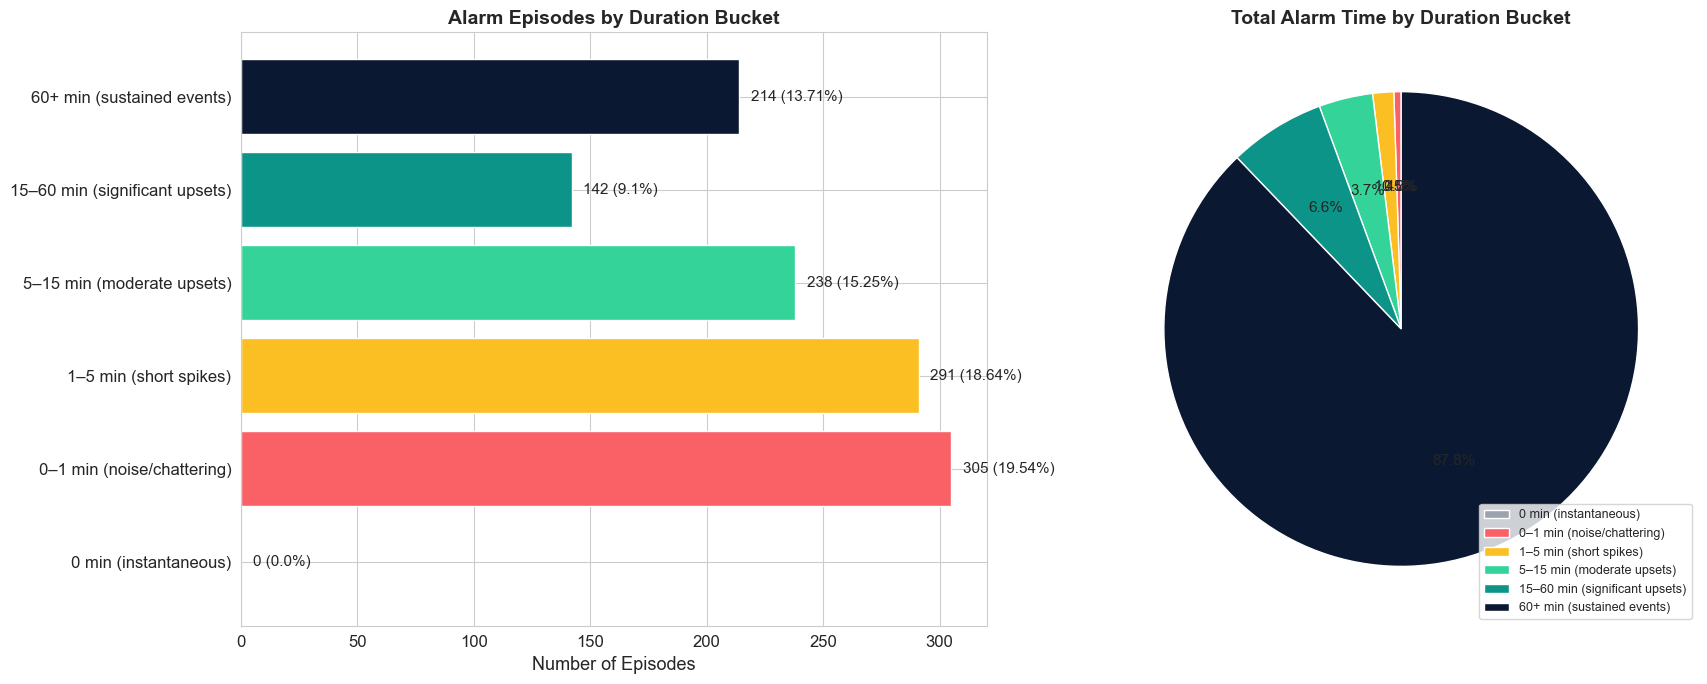

Saved: alarm_duration_windowing.png


,Bucket,Episode_Count,Total_Duration_Minutes,Pct_of_Episodes
0,0 min (instantaneous),0,0.0,0.00
1,0–1 min (noise/chattering),305,305.0,19.54
2,1–5 min (short spikes),291,880.0,18.64
3,5–15 min (moderate upsets),238,2250.0,15.25
4,15–60 min (significant upsets),142,4018.0,9.10
5,60+ min (sustained events),214,53824.0,13.71


In [32]:
# Duration Windowing — Bucket alarm episodes
bins = [0, 0.001, 1, 5, 15, 60, float('inf')]
labels = ['0 min (instantaneous)',
          '0–1 min (noise/chattering)',
          '1–5 min (short spikes)',
          '5–15 min (moderate upsets)',
          '15–60 min (significant upsets)',
          '60+ min (sustained events)']

events_df['Duration_Bucket'] = pd.cut(events_df['Duration_Minutes'], bins=bins, labels=labels, right=True)
bucket_counts = events_df['Duration_Bucket'].value_counts().reindex(labels)
bucket_duration = events_df.groupby('Duration_Bucket', observed=False)['Duration_Minutes'].sum().reindex(labels)

bucket_report = pd.DataFrame({
    'Bucket': labels,
    'Episode_Count': bucket_counts.values,
    'Total_Duration_Minutes': bucket_duration.values.round(2),
    'Pct_of_Episodes': (bucket_counts.values / len(events_df) * 100).round(2)
})
save_output_to_csv(bucket_report, OUTPUT_DIR, "alarm_duration_buckets.csv")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart: episode count per bucket
colors = ['#9CA3AF', '#F96167', '#FBBF24', '#34D399', '#0D9488', '#0A1931']
axes[0].barh(labels, bucket_counts.values, color=colors, edgecolor='white')
axes[0].set_xlabel("Number of Episodes")
axes[0].set_title("Alarm Episodes by Duration Bucket", fontsize=14, fontweight='bold')
for i, (val, pct) in enumerate(zip(bucket_counts.values, bucket_report['Pct_of_Episodes'])):
    axes[0].text(val + 5, i, f'{val} ({pct}%)', va='center', fontsize=11)

# Pie chart: total alarm duration per bucket
axes[1].pie(bucket_duration.values, labels=None, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title("Total Alarm Time by Duration Bucket", fontsize=14, fontweight='bold')
axes[1].legend(labels, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "alarm_duration_windowing.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: alarm_duration_windowing.png")
display(bucket_report)

In [33]:
# Chattering Detection
# Definition: Episodes ≤ 1 minute, followed by another episode within 5 minutes
events_sorted = events_df.sort_values('Alarm_Start').reset_index(drop=True)
events_sorted['Next_Start'] = events_sorted['Alarm_Start'].shift(-1)
events_sorted['Gap_To_Next'] = (events_sorted['Next_Start'] - events_sorted['Alarm_End']).dt.total_seconds() / 60

# Flag chattering: short duration AND short gap to next episode
chattering_mask = (events_sorted['Duration_Minutes'] <= 1) & (events_sorted['Gap_To_Next'] <= 5)
chattering_df = events_sorted[chattering_mask].copy()

print(f"\n{'='*60}")
print(f"CHATTERING ANALYSIS")
print(f"{'='*60}")
print(f"Chattering episodes (≤1 min duration, ≤5 min gap to next): {len(chattering_df)}")
print(f"Total chattering time: {chattering_df['Duration_Minutes'].sum():.2f} minutes")
print(f"Chattering as % of all episodes: {len(chattering_df)/len(events_df)*100:.2f}%")

if not chattering_df.empty:
    # Identify chattering sequences (groups of rapid on/off)
    chattering_df['Sequence_ID'] = (chattering_df.index.to_series().diff() > 1).cumsum()
    seq_counts = chattering_df.groupby('Sequence_ID').size()
    print(f"\nChattering sequences identified: {seq_counts.nunique()}")
    print(f"Longest chattering sequence: {seq_counts.max()} rapid episodes")
    save_output_to_csv(chattering_df[['Alarm_Start', 'Alarm_End', 'Duration_Minutes', 'Gap_To_Next']],
                       OUTPUT_DIR, "chattering_report.csv")
    display(chattering_df[['Alarm_Start', 'Alarm_End', 'Duration_Minutes', 'Gap_To_Next']].head(15))
else:
    print("No chattering episodes detected.")


CHATTERING ANALYSIS
Chattering episodes (≤1 min duration, ≤5 min gap to next): 359
Total chattering time: 180.00 minutes
Chattering as % of all episodes: 23.00%

Chattering sequences identified: 7
Longest chattering sequence: 7 rapid episodes
Saved to outputs\eda_reports\chattering_report.csv


,Alarm_Start,Alarm_End,Duration_Minutes,Gap_To_Next
20,2022-05-23 13:31:00,2022-05-23 13:32:00,1.0,3.0
22,2022-05-23 13:49:00,2022-05-23 13:49:00,0.0,4.0
23,2022-05-23 13:53:00,2022-05-23 13:53:00,0.0,3.0
29,2022-05-30 13:27:00,2022-05-30 13:28:00,1.0,2.0
30,2022-05-30 13:30:00,2022-05-30 13:30:00,0.0,3.0
31,2022-05-30 13:33:00,2022-05-30 13:34:00,1.0,3.0
32,2022-05-30 13:37:00,2022-05-30 13:37:00,0.0,2.0
34,2022-05-30 16:32:00,2022-05-30 16:33:00,1.0,3.0
35,2022-05-30 16:36:00,2022-05-30 16:36:00,0.0,3.0
38,2022-05-30 17:06:00,2022-05-30 17:07:00,1.0,2.0


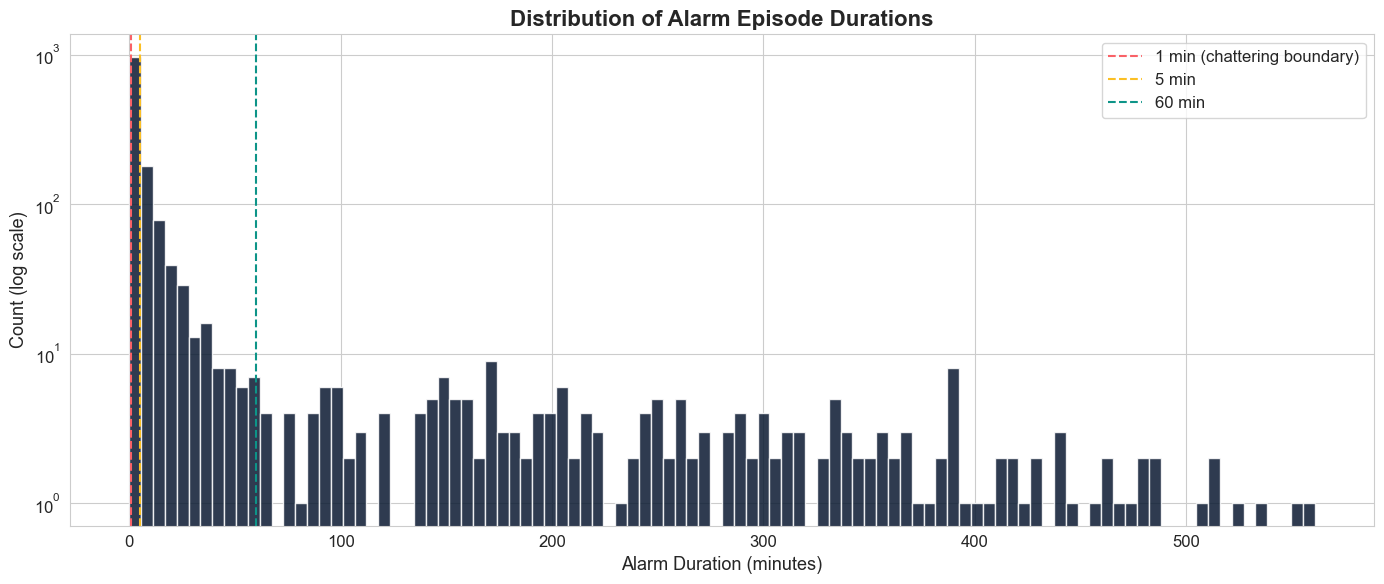

Saved: alarm_duration_histogram.png


In [34]:
# Histogram of alarm durations (log scale)
fig, ax = plt.subplots(figsize=(14, 6))
ax.hist(events_df['Duration_Minutes'], bins=100, color='#0A1931', edgecolor='white', alpha=0.85, log=True)
ax.set_xlabel("Alarm Duration (minutes)")
ax.set_ylabel("Count (log scale)")
ax.set_title("Distribution of Alarm Episode Durations", fontsize=16, fontweight='bold')
ax.axvline(1, color='#F96167', linestyle='--', label='1 min (chattering boundary)')
ax.axvline(5, color='#FBBF24', linestyle='--', label='5 min')
ax.axvline(60, color='#0D9488', linestyle='--', label='60 min')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "alarm_duration_histogram.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: alarm_duration_histogram.png")

In [35]:
# Filter alarm episodes greater than 60 minutes (sustained events)
sustained_alarms = events_df[events_df['Duration_Minutes'] > 60].copy()
print(f"Total sustained alarm episodes (>60 mins): {len(sustained_alarms)}")

# Save to outputs folder
sustained_alarms_path = "outputs/sustained_alarms_greater_than_60m.csv"
os.makedirs(os.path.dirname(sustained_alarms_path), exist_ok=True)
sustained_alarms.to_csv(sustained_alarms_path, index=False)
print(f"Saved sustained alarms to {sustained_alarms_path}")

# Display the first few sustained alarm episodes
display(sustained_alarms.head())

Total sustained alarm episodes (>60 mins): 214
Saved sustained alarms to outputs/sustained_alarms_greater_than_60m.csv


,Alarm_Start,Alarm_End,Duration_Minutes,Duration_Bucket
15,2022-04-14 13:10:00,2022-04-14 16:12:00,182.0,60+ min (sustained events)
25,2022-05-23 14:12:00,2022-05-23 18:16:00,244.0,60+ min (sustained events)
33,2022-05-30 13:39:00,2022-05-30 16:29:00,170.0,60+ min (sustained events)
40,2022-05-31 12:52:00,2022-05-31 15:18:00,146.0,60+ min (sustained events)
50,2022-06-01 14:26:00,2022-06-01 16:58:00,152.0,60+ min (sustained events)


---
## 9. Pre-Alarm & Post-Alarm Behavior Analysis

For each alarm episode, analyze what ALL sensors were doing at **10 min, 30 min, and 60 min** before and after the alarm.

In [36]:
# Set up time-indexed data for lookups
df_ts = df_imputed.copy()
if df_ts.index.name != 'TimeStamp':
    if 'TimeStamp' in df_ts.columns:
        df_ts = df_ts.set_index('TimeStamp')

sensor_cols_analysis = [c for c in df_ts.columns if c != 'TimeStamp']
windows = [10, 30, 60]  # minutes before/after

# Analyze pre-alarm behavior for each window
pre_alarm_stats = {w: [] for w in windows}
post_alarm_stats = {w: [] for w in windows}

for _, event in events_sorted.iterrows():
    alarm_start = event['Alarm_Start']
    alarm_end = event['Alarm_End']
    
    for w in windows:
        # Pre-alarm window
        pre_start = alarm_start - pd.Timedelta(minutes=w)
        pre_data = df_ts.loc[pre_start:alarm_start]
        
        if len(pre_data) > 1:
            # Rate of change for each sensor
            roc = {}
            for col in sensor_cols_analysis:
                vals = pre_data[col].dropna()
                if len(vals) >= 2:
                    roc[f'{col}_roc'] = (vals.iloc[-1] - vals.iloc[0]) / w
                    roc[f'{col}_mean'] = vals.mean()
                    roc[f'{col}_std'] = vals.std()
            pre_alarm_stats[w].append(roc)
        
        # Post-alarm window
        post_end = alarm_end + pd.Timedelta(minutes=w)
        post_data = df_ts.loc[alarm_end:post_end]
        
        if len(post_data) > 1:
            roc = {}
            for col in sensor_cols_analysis:
                vals = post_data[col].dropna()
                if len(vals) >= 2:
                    roc[f'{col}_roc'] = (vals.iloc[-1] - vals.iloc[0]) / w
                    roc[f'{col}_mean'] = vals.mean()
                    roc[f'{col}_std'] = vals.std()
            post_alarm_stats[w].append(roc)

print("Pre/Post alarm behavior computed for windows:", windows, "minutes")

Pre/Post alarm behavior computed for windows: [10, 30, 60] minutes


In [37]:
# Summarize average pre-alarm rate-of-change for the TARGET tag
print(f"\n{'='*70}")
print(f"PRE-ALARM BEHAVIOR — Average Rate of Change for {TARGET_TAG}")
print(f"{'='*70}")

target_roc_col = f'{TARGET_TAG}_roc'
for w in windows:
    if pre_alarm_stats[w]:
        rocs = [s[target_roc_col] for s in pre_alarm_stats[w] if target_roc_col in s]
        if rocs:
            print(f"  {w} min before alarm: avg RoC = {np.mean(rocs):+.4f} °C/min "
                  f"(median: {np.median(rocs):+.4f}, std: {np.std(rocs):.4f})")

print(f"\n{'='*70}")
print(f"POST-ALARM BEHAVIOR — Average Rate of Change for {TARGET_TAG}")
print(f"{'='*70}")
for w in windows:
    if post_alarm_stats[w]:
        rocs = [s[target_roc_col] for s in post_alarm_stats[w] if target_roc_col in s]
        if rocs:
            print(f"  {w} min after alarm end: avg RoC = {np.mean(rocs):+.4f} °C/min "
                  f"(median: {np.median(rocs):+.4f}, std: {np.std(rocs):.4f})")


PRE-ALARM BEHAVIOR — Average Rate of Change for 03TIC_1023.PV
  10 min before alarm: avg RoC = +0.0285 °C/min (median: +0.0237, std: 0.0756)
  30 min before alarm: avg RoC = +0.0132 °C/min (median: +0.0119, std: 0.0361)
  60 min before alarm: avg RoC = +0.0117 °C/min (median: +0.0117, std: 0.0223)

POST-ALARM BEHAVIOR — Average Rate of Change for 03TIC_1023.PV
  10 min after alarm end: avg RoC = -0.0387 °C/min (median: -0.0283, std: 0.0760)
  30 min after alarm end: avg RoC = -0.0165 °C/min (median: -0.0111, std: 0.0388)
  60 min after alarm end: avg RoC = -0.0121 °C/min (median: -0.0101, std: 0.0249)


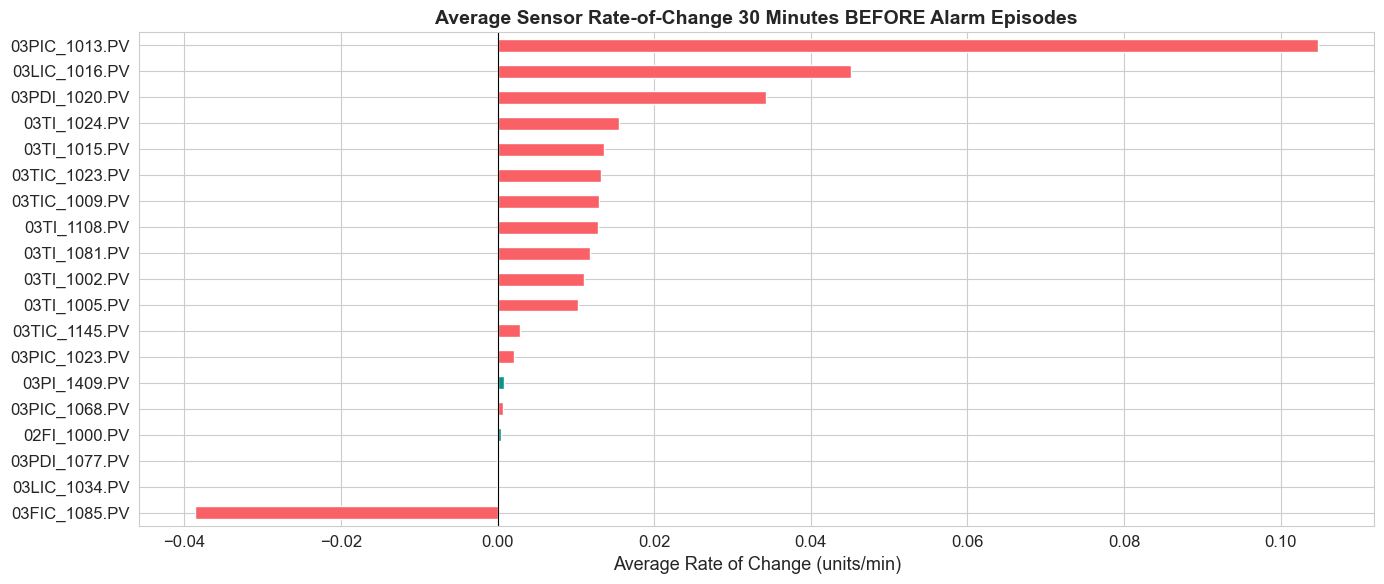

Saved: pre_alarm_roc_heatmap.png


Saved to outputs\eda_reports\pre_alarm_behavior_30m.csv


In [38]:
# Heatmap: average sensor rate-of-change BEFORE alarm (30-min window)
w = 30
if pre_alarm_stats[w]:
    roc_cols = [f'{c}_roc' for c in sensor_cols_analysis]
    pre_df = pd.DataFrame(pre_alarm_stats[w])
    roc_avgs = pre_df[[c for c in roc_cols if c in pre_df.columns]].mean()
    roc_avgs.index = [c.replace('_roc', '') for c in roc_avgs.index]
    
    fig, ax = plt.subplots(figsize=(14, 6))
    colors_bar = ['#F96167' if v > 0 else '#0D9488' for v in roc_avgs.values]
    roc_avgs.sort_values().plot(kind='barh', color=colors_bar, ax=ax, edgecolor='white')
    ax.set_xlabel("Average Rate of Change (units/min)")
    ax.set_title(f"Average Sensor Rate-of-Change {w} Minutes BEFORE Alarm Episodes",
                 fontsize=14, fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "pre_alarm_roc_heatmap.png"), dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: pre_alarm_roc_heatmap.png")
    
    # Save detailed pre-alarm stats
    save_output_to_csv(pre_df.describe().T.reset_index(), OUTPUT_DIR, "pre_alarm_behavior_30m.csv")

In [39]:
# Superimposed alarm event profiles — target temperature aligned by alarm start
fig = go.Figure()

# Plot up to 50 representative alarm profiles
sample_events = events_sorted.sample(n=min(50, len(events_sorted)), random_state=42)

for _, event in sample_events.iterrows():
    start = event['Alarm_Start'] - pd.Timedelta(minutes=60)
    end = event['Alarm_End'] + pd.Timedelta(minutes=60)
    segment = df_ts.loc[start:end, TARGET_TAG].dropna()
    
    if len(segment) > 0:
        # Align x-axis: minutes relative to alarm start
        x_mins = (segment.index - event['Alarm_Start']).total_seconds() / 60
        fig.add_trace(go.Scattergl(
            x=x_mins, y=segment.values,
            mode='lines', opacity=0.3, line=dict(width=1, color='#0A1931'),
            showlegend=False
        ))

fig.add_hline(y=ALARM_THRESHOLD, line_dash="dash", line_color="red",
              annotation_text=f"Alarm Threshold ({ALARM_THRESHOLD}°C)")
fig.add_vline(x=0, line_dash="dash", line_color="orange",
              annotation_text="Alarm Start")
fig.update_layout(
    title="Superimposed Alarm Event Profiles (50 samples, aligned by alarm start)",
    xaxis_title="Minutes Relative to Alarm Start",
    yaxis_title=f"{TARGET_TAG} (°C)",
    template="plotly_white",
    height=500
)
fig.show()

---
## 10. Post-Trip False Alarm Verification

> **Client Requirement:** Check if any alarm episodes occur shortly after plant trips/shutdowns.  
> Alarms within 10m, 20m, 60m, 120m of trip end times may be **false alarms** caused by residual thermal transients during restart.

In [40]:
# Check alarm episodes occurring after each trip end
verification_windows = [10, 20, 60, 120]  # minutes after trip end

post_trip_results = []
for _, trip in trip_df.iterrows():
    trip_end = trip['trip_end']
    
    for window in verification_windows:
        window_end = trip_end + pd.Timedelta(minutes=window)
        
        # Find alarm episodes starting within this window
        mask = (events_sorted['Alarm_Start'] >= trip_end) & (events_sorted['Alarm_Start'] <= window_end)
        matching = events_sorted[mask]
        
        for _, alarm in matching.iterrows():
            post_trip_results.append({
                'Trip_End': trip_end,
                'Window_Minutes': window,
                'Alarm_Start': alarm['Alarm_Start'],
                'Alarm_End': alarm['Alarm_End'],
                'Alarm_Duration_Min': alarm['Duration_Minutes'],
                'Minutes_After_Trip': (alarm['Alarm_Start'] - trip_end).total_seconds() / 60
            })

post_trip_df = pd.DataFrame(post_trip_results)

# Summary by window
print(f"{'='*70}")
print(f"POST-TRIP FALSE ALARM VERIFICATION")
print(f"{'='*70}")

for w in verification_windows:
    subset = post_trip_df[post_trip_df['Window_Minutes'] == w] if not post_trip_df.empty else pd.DataFrame()
    unique_alarms = subset['Alarm_Start'].nunique() if not subset.empty else 0
    print(f"  Within {w:>3} min of trip end: {unique_alarms} alarm episodes detected")

if not post_trip_df.empty:
    # Deduplicate (same alarm may appear in multiple windows)
    unique_post_trip = post_trip_df.drop_duplicates(subset=['Alarm_Start']).sort_values('Alarm_Start')
    save_output_to_csv(unique_post_trip, OUTPUT_DIR, "post_trip_alarm_verification.csv")
    print(f"\nTotal unique post-trip alarms: {len(unique_post_trip)}")
    print(f"These may be false alarms caused by thermal transients during restart.")
    display(unique_post_trip.head(15))
else:
    print("\n✅ No alarm episodes found near trip end times — trip data was properly removed.")

POST-TRIP FALSE ALARM VERIFICATION
  Within  10 min of trip end: 2 alarm episodes detected
  Within  20 min of trip end: 2 alarm episodes detected
  Within  60 min of trip end: 9 alarm episodes detected
  Within 120 min of trip end: 12 alarm episodes detected
Saved to outputs\eda_reports\post_trip_alarm_verification.csv

Total unique post-trip alarms: 12
These may be false alarms caused by thermal transients during restart.


,Trip_End,Window_Minutes,Alarm_Start,Alarm_End,Alarm_Duration_Min,Minutes_After_Trip
4,2022-08-06 17:00:00,60,2022-08-06 17:47:00,2022-08-06 17:57:00,10.0,47.0
6,2022-08-06 17:00:00,120,2022-08-06 18:04:00,2022-08-06 18:09:00,5.0,64.0
0,2023-01-04 09:52:00,10,2023-01-04 09:53:00,2023-01-04 10:19:00,26.0,1.0
7,2023-02-06 16:20:00,120,2023-02-06 18:07:00,2023-02-06 18:10:00,3.0,107.0
8,2023-02-10 03:30:00,10,2023-02-10 03:34:00,2023-02-10 03:35:00,1.0,4.0
12,2023-06-05 10:05:00,60,2023-06-05 11:02:00,2023-06-05 11:03:00,1.0,57.0
14,2024-06-27 15:52:00,60,2024-06-27 16:20:00,2024-06-27 16:32:00,12.0,28.0
15,2024-06-27 15:52:00,60,2024-06-27 16:34:00,2024-06-27 16:34:00,0.0,42.0
16,2024-06-27 15:52:00,60,2024-06-27 16:38:00,2024-06-27 16:39:00,1.0,46.0
17,2024-06-27 15:52:00,60,2024-06-27 16:42:00,2024-06-27 16:43:00,1.0,50.0


In [41]:
# Timeline visualization: trips and nearby alarm episodes
fig = go.Figure()

# Plot trips as vertical shaded regions (sample up to 30)
for _, trip in trip_df.head(30).iterrows():
    fig.add_vrect(x0=trip['trip_start'], x1=trip['trip_end'],
                  fillcolor="red", opacity=0.15, line_width=0)

# Plot alarm episodes as markers
for _, event in events_sorted.iterrows():
    fig.add_trace(go.Scattergl(
        x=[event['Alarm_Start']], y=[event['Duration_Minutes']],
        mode='markers',
        marker=dict(color='#0A1931', size=4, opacity=0.4),
        showlegend=False
    ))

# Highlight post-trip alarms
if not post_trip_df.empty:
    post_trip_unique = post_trip_df.drop_duplicates(subset=['Alarm_Start'])
    fig.add_trace(go.Scatter(
        x=post_trip_unique['Alarm_Start'],
        y=post_trip_unique['Alarm_Duration_Min'],
        mode='markers',
        marker=dict(color='red', size=10, symbol='x'),
        name='Post-Trip Alarms (potential false)'
    ))

fig.update_layout(
    title="Alarm Episodes Timeline with Trip Periods (red zones = trip shutdowns)",
    xaxis_title="Date",
    yaxis_title="Alarm Duration (minutes)",
    template="plotly_white",
    height=450,
    yaxis_type="log"
)
fig.show()

---
## 11. Alarm Distribution Across Train / Val / Test Splits

> **Client Requirement:** Data splits should have well-distributed alarms across training, validation, and test sets.

In [42]:
# Assign events to splits based on Alarm_Start
def assign_split(ts):
    if ts <= TRAIN_END:
        return 'Train (2022-2025)'
    elif ts <= VAL_END:
        return 'Val (Mid 2025)'
    else:
        return 'Test (Late 2025)'

events_sorted['Split'] = events_sorted['Alarm_Start'].apply(assign_split)

# Also check row-level alarm distribution in the imputed data
df_check = df_imputed.copy()
df_check['split'] = df_check.index.map(assign_split)
df_check['in_alarm'] = df_check[TARGET_TAG] >= ALARM_THRESHOLD

# Summary table
split_summary = []
total_ep = len(events_sorted)
for split_name in ['Train (2022-2025)', 'Val (Mid 2025)', 'Test (Late 2025)']:
    subset = df_check[df_check['split'] == split_name]
    alarm_rows = subset['in_alarm'].sum()
    total_rows = len(subset)
    ep_subset = events_sorted[events_sorted['Split'] == split_name]
    
    split_summary.append({
        'Split': split_name,
        'Total_Rows': total_rows,
        'Num_Episodes': len(ep_subset),
        'Episode_Pct': round(len(ep_subset) / total_ep * 100, 2) if total_ep > 0 else 0,
        'Avg_Episode_Duration_Min': round(ep_subset['Duration_Minutes'].mean(), 2) if len(ep_subset) > 0 else 0,
        'Alarm_Rows': int(alarm_rows),
        'Normal_Rows': int(total_rows - alarm_rows),
        'Alarm_Pct': round(alarm_rows / total_rows * 100, 3) if total_rows > 0 else 0,
        'Median_Episode_Duration_Min': round(ep_subset['Duration_Minutes'].median(), 2) if len(ep_subset) > 0 else 0
    })

split_df = pd.DataFrame(split_summary)
save_output_to_csv(split_df, OUTPUT_DIR, "split_alarm_distribution.csv")

print(f"{'='*80}")
print(f"ALARM DISTRIBUTION ACROSS CHRONOLOGICAL SPLITS")
print(f"{'='*80}")
display(split_df)

# Assessment
alarm_pcts = split_df['Alarm_Pct'].values
pct_range = max(alarm_pcts) - min(alarm_pcts)
if pct_range < 1.5:
    print(f"\n✅ GOOD: Alarm percentage is well-distributed (range: {pct_range:.2f}% across splits)")
elif pct_range < 3.0:
    print(f"\n⚠️ MODERATE: Some variation in alarm distribution (range: {pct_range:.2f}%)")
else:
    print(f"\n❌ WARNING: Significant alarm distribution imbalance (range: {pct_range:.2f}%)")
    print("   Consider adjusting split boundaries or using stratified time-series splitting.")

Saved to outputs\eda_reports\split_alarm_distribution.csv
ALARM DISTRIBUTION ACROSS CHRONOLOGICAL SPLITS


,Split,Total_Rows,Num_Episodes,Episode_Pct,Avg_Episode_Duration_Min,Alarm_Rows,Normal_Rows,Alarm_Pct,Median_Episode_Duration_Min
0,Train (2022-2025),1808715,1169,74.89,43.67,52218,1756497,2.887,4.0
1,Val (Mid 2025),83520,199,12.75,37.72,7705,75815,9.225,1.0
2,Test (Late 2025),220290,193,12.36,14.10,2914,217376,1.323,1.0



❌ WARNING: Significant alarm distribution imbalance (range: 7.90%)
   Consider adjusting split boundaries or using stratified time-series splitting.


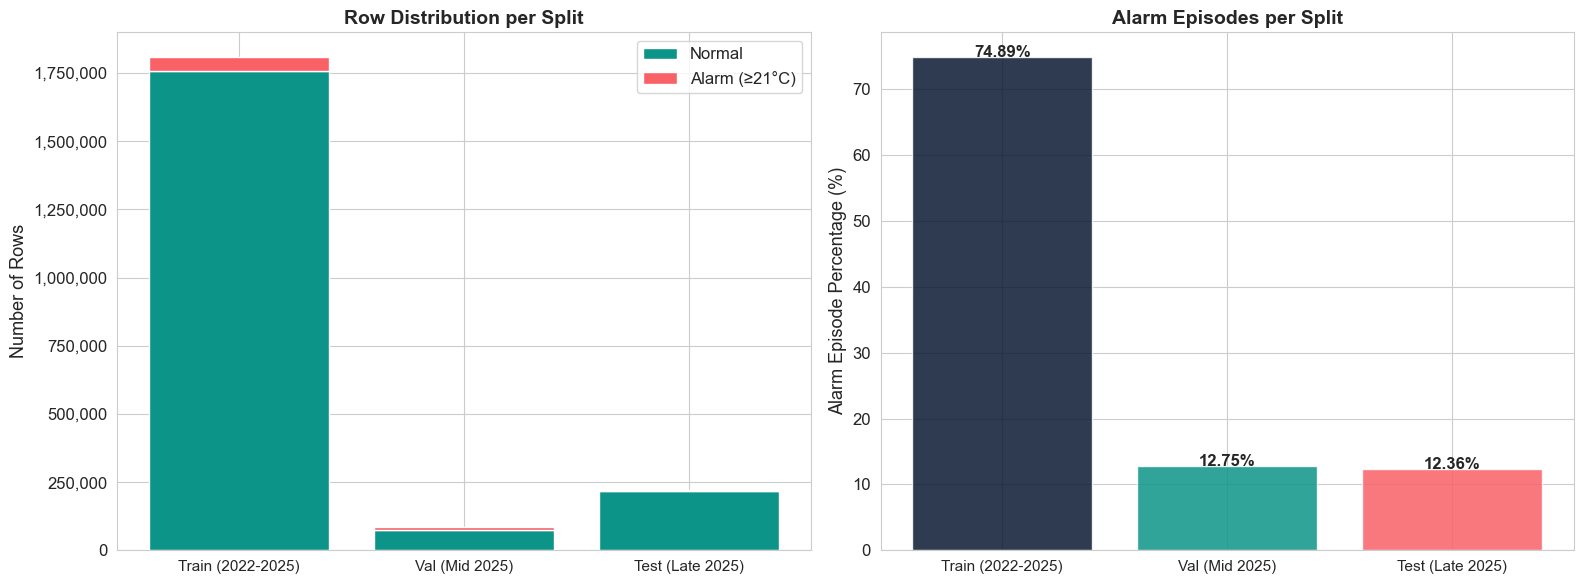

Saved: split_alarm_distribution.png


In [43]:
# Visualization: stacked bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Absolute counts
x = range(len(split_df))
axes[0].bar(x, split_df['Normal_Rows'], label='Normal', color='#0D9488', edgecolor='white')
axes[0].bar(x, split_df['Alarm_Rows'], bottom=split_df['Normal_Rows'],
            label='Alarm (≥21°C)', color='#F96167', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(split_df['Split'], fontsize=11)
axes[0].set_ylabel("Number of Rows")
axes[0].set_title("Row Distribution per Split", fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Alarm percentage comparison
split_df['Episode_Pct'] = split_df['Num_Episodes'] / split_df['Num_Episodes'].sum() * 100
axes[1].bar(x, split_df['Episode_Pct'], color=['#0A1931', '#0D9488', '#F96167'],
            edgecolor='white', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(split_df['Split'], fontsize=11)
axes[1].set_ylabel("Alarm Episode Percentage (%)")
axes[1].set_title("Alarm Episodes per Split", fontsize=14, fontweight='bold')
for i, v in enumerate(split_df['Episode_Pct']):
    axes[1].text(i, v + 0.05, f'{v:.2f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "split_alarm_distribution.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: split_alarm_distribution.png")

---
## 12. Monthly & Seasonal Alarm Trends

Identify seasonal patterns and peak alarm periods.

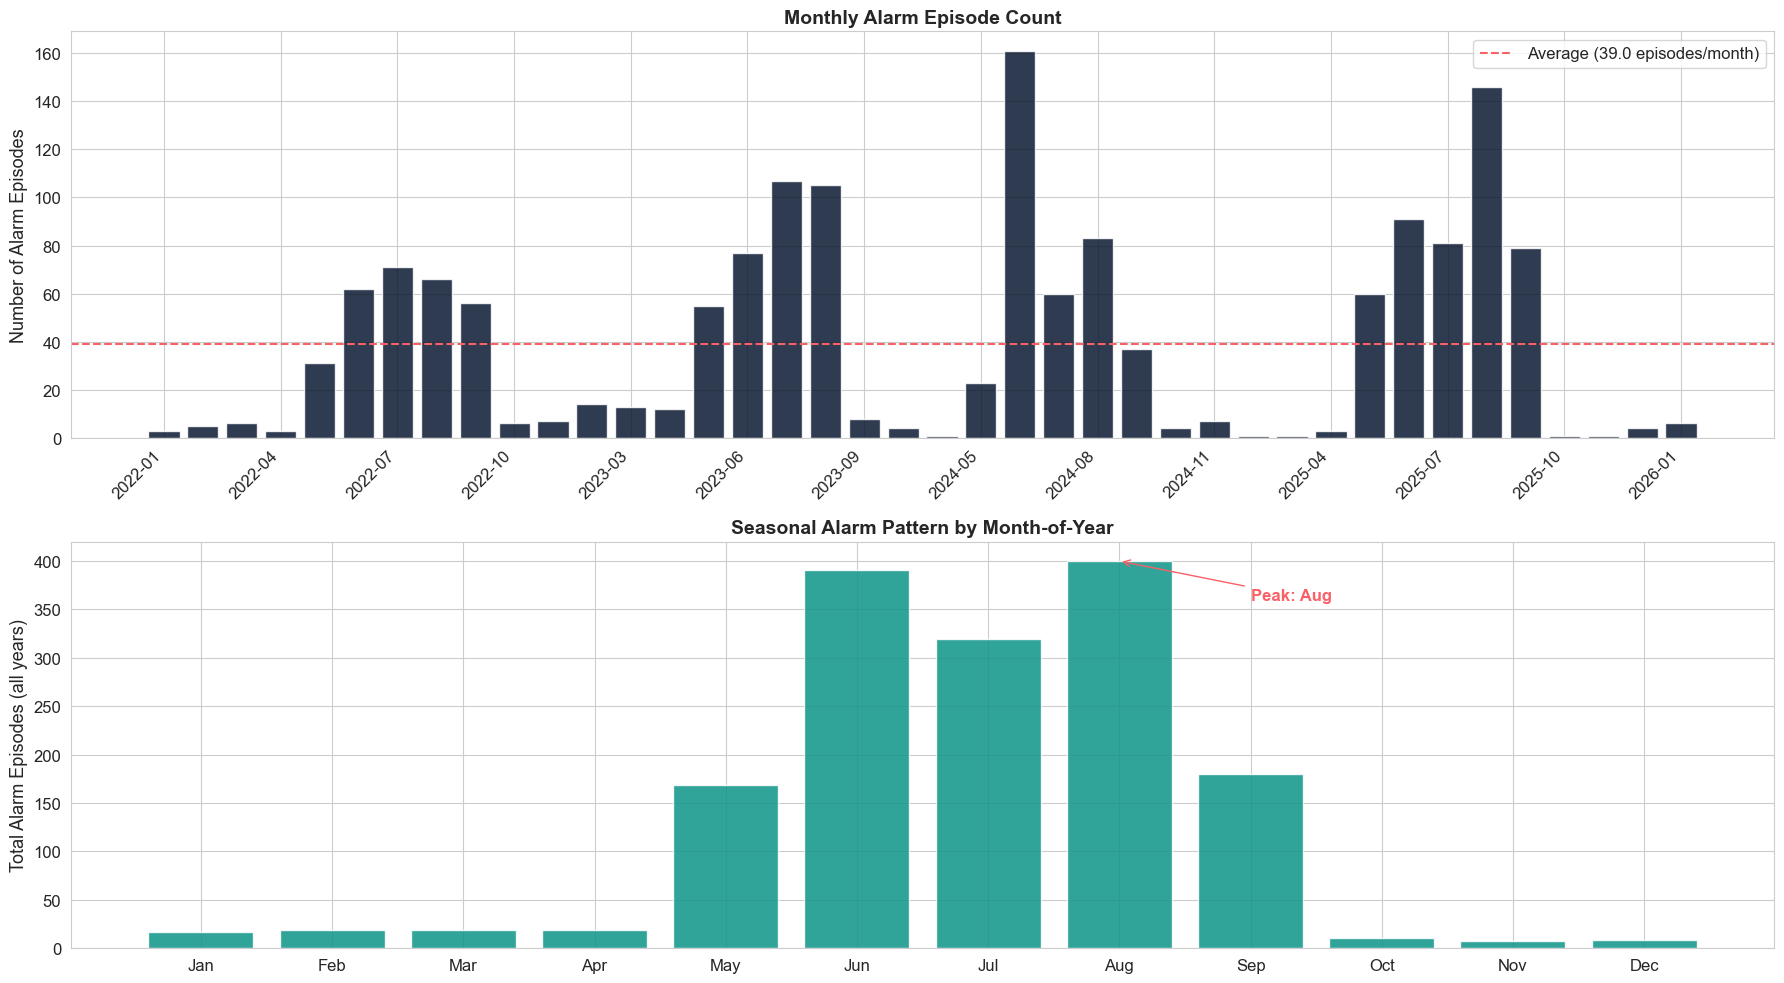

Saved: monthly_seasonal_trends.png


In [44]:
# Monthly alarm episode count over time
events_sorted['Year_Month'] = events_sorted['Alarm_Start'].dt.to_period('M')
monthly_counts = events_sorted.groupby('Year_Month').size()

fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# Time series of monthly alarm counts
axes[0].bar(range(len(monthly_counts)), monthly_counts.values, color='#0A1931', edgecolor='white', alpha=0.85)
axes[0].set_xticks(range(0, len(monthly_counts), 3))
axes[0].set_xticklabels([str(p) for p in monthly_counts.index[::3]], rotation=45, ha='right')
axes[0].set_ylabel("Number of Alarm Episodes")
axes[0].set_title("Monthly Alarm Episode Count", fontsize=14, fontweight='bold')
axes[0].axhline(monthly_counts.mean(), color='#F96167', linestyle='--',
                label=f'Average ({monthly_counts.mean():.1f} episodes/month)')
axes[0].legend()

# Seasonal pattern: alarm rate by month-of-year
events_sorted['Month_Name'] = events_sorted['Alarm_Start'].dt.month_name()
monthly_pattern = events_sorted.groupby(events_sorted['Alarm_Start'].dt.month).size()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_vals = [monthly_pattern.get(i+1, 0) for i in range(12)]

axes[1].bar(range(12), monthly_vals, color='#0D9488', edgecolor='white', alpha=0.85)
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(month_names)
axes[1].set_ylabel("Total Alarm Episodes (all years)")
axes[1].set_title("Seasonal Alarm Pattern by Month-of-Year", fontsize=14, fontweight='bold')

# Highlight peak months
peak_month = month_names[np.argmax(monthly_vals)]
axes[1].annotate(f'Peak: {peak_month}', xy=(np.argmax(monthly_vals), max(monthly_vals)),
                 fontsize=12, fontweight='bold', color='#F96167',
                 xytext=(np.argmax(monthly_vals)+1, max(monthly_vals)*0.9),
                 arrowprops=dict(arrowstyle='->', color='#F96167'))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "monthly_seasonal_trends.png"), dpi=150, bbox_inches='tight')
plt.show()
print("Saved: monthly_seasonal_trends.png")

In [45]:
# Year-over-year comparison
yearly = events_sorted.groupby(events_sorted['Alarm_Start'].dt.year).agg(
    Episodes=('Duration_Minutes', 'count'),
    Total_Alarm_Time_Min=('Duration_Minutes', 'sum'),
    Avg_Duration_Min=('Duration_Minutes', 'mean'),
    Max_Duration_Min=('Duration_Minutes', 'max')
).round(2)
yearly.index.name = 'Year'
save_output_to_csv(yearly.reset_index(), OUTPUT_DIR, "yearly_alarm_summary.csv")
print("Year-over-Year Alarm Summary:")
display(yearly)

Saved to outputs\eda_reports\yearly_alarm_summary.csv
Year-over-Year Alarm Summary:


,Episodes,Total_Alarm_Time_Min,Avg_Duration_Min,Max_Duration_Min
Year,,,,
2022,309,20147.0,65.20,508.0
2023,402,9742.0,24.23,353.0
2024,377,18749.0,49.73,535.0
2025,467,12628.0,27.04,561.0
2026,6,11.0,1.83,4.0


---
## 12b. Interactive Tags Trend (All Sensors)

Use the client's `plot_tags_trend()` for interactive sensor visualization.

In [46]:
# Interactive trend plot using client utility (downsampled for performance)
df_trend = df_for_events.copy()
fig_trend = plot_tags_trend(df_trend, downsample=10,
                            title="All Sensor Tags — Interactive Trend (1-in-10 downsample)")
try:
    fig_trend.write_html(os.path.join(OUTPUT_DIR, "tags_trend_interactive.html"))
    print("Saved: tags_trend_interactive.html")
except:
    print("Interactive trend displayed inline.")

---
# Part 2: Feature Selection & Feature Engineering

## 13. Feature Selection Strategy

Before generating temporal features (lags, rolling stats), we must select which raw variables are suitable for our predictive model. We do not want to engineer features for all 19 sensors to avoid the curse of dimensionality and redundancy.

### Feature Selection Rules:
1. **Target Correlation Filter**: We evaluate the correlation of each of the 19 sensors with our target `03TIC_1023.PV` using three methods: Pearson ($r$), Spearman ($\rho$), and Distance Correlation ($d_c$). We keep variables with an average absolute correlation $\ge 0.50$.
2. **Inter-Variable Collinearity Filter**: If two sensors are extremely highly correlated with each other ($|r| \ge 0.95$), they represent redundant information. We keep the one with the higher correlation to the target and drop the other from key lag/rolling feature engineering.
3. **Physical Context**: We prioritize keeping pressure and temperature sensors because they represent different physical properties governed by vapor-liquid equilibrium (VLE).

### Variable-by-Variable Reasoning:
* `03TIC_1023.PV` (Target Overhead Temperature): **KEEP**. This is our target variable.
* `03TI_1024.PV` (Column Bottom Inlet Temperature): **KEEP**. Highly correlated with target ($r = 0.984$), represents bottom column thermal rise which physically drives overhead temperature.
* `03TI_1015.PV` (C3 Inlet Temperature): **EXCLUDE FROM KEY LAGS (Collinear)**. It is $98.96\%$ correlated with `03TI_1024.PV`, representing a redundant temperature measurement. We exclude it from heavy lag/rolling feature generation to avoid dimensional redundancy.
* `03PIC_1023.PV` (C3 Separator Pressure): **KEEP**. Highly correlated ($r = 0.965$), represents system pressure which directly governs boiling point.
* `03TI_1081.PV` (Temperature Indicator): **KEEP**. Moderately correlated ($r = 0.729$), represents downstream cooling temperature feedback.
* `03TIC_1009.PV` (Temperature Controller): **KEEP**. Moderately correlated ($r = 0.559$), regulates column feed temperature.
* `03PIC_1013.PV`, `03TI_1005.PV`, `03TI_1108.PV`: **EXCLUDE FROM KEY LAGS**. While their target correlation is above 0.50, they are redundant with other feed/cooling parameters (e.g., `03TI_1108.PV` is 93.0% correlated with `03TIC_1009.PV`).
* All other sensors (`02FI_1000.PV`, `03FIC_1085.PV`, `03LIC_1016.PV`, `03LIC_1034.PV`, `03PDI_1020.PV`, `03PDI_1077.PV`, `03PIC_1068.PV`, `03PI_1409.PV`, `03TIC_1145.PV`, `03TI_1002.PV`): **EXCLUDE FROM KEY LAGS**. Their correlations with the target are too low ($< 0.50$). They are kept as raw features in the training dataset, but we do not build lag/rolling windows for them.

## 14. Feature Engineering Pipeline

### Why we do NOT remove engineered features based on correlation:
1. **LightGBM Handles Collinearity Natively**: Decision trees split on one feature at a time, selecting the split that maximizes information gain. If two features are highly correlated (e.g., a 5-minute lag and a 10-minute lag, or a sensor and its rolling average), LightGBM will split on the most informative one and ignore the redundant one. Unlike linear models, tree-based models do not experience numerical instability in the presence of multicollinearity.
2. **Temporal Value of Offsets**: Lags and differences capture temporal dynamics (momentum, velocity, and baselines). Even if globally correlated, they diverge during transient phases (e.g., rapid temperature rises), which is exactly how the model detects impending alarms. Removing them would strip the model of its predictive eyes.
3. **Information Loss Risk**: Dropping a rolling mean because it's correlated with the raw value removes baseline context, preventing the model from knowing if a temperature is rising relative to its average.

### Engineered Features:
1. **Ambient Time Features**: `hour`, `month`, `dayofweek`.
2. **Lag Features**: Lags of 1, 2, 5, 10, 15, 30, 60 minutes for key columns.
3. **Rolling Window Features**: Mean, standard deviation, max, and min over 10m, 30m, and 60m windows for key columns.
4. **Rate of Change (Differences)**: Difference over 5, 15, 30 minutes for key columns.

### 14.1. SME Q&A: Why We Choose These Features & Do Not Filter Engineered Features

#### Q1: On which core features did you build new features (lags, rolling stats), and why?
* **Core Sensors Selected**: We selected 5 key sensors out of the 19 raw process parameters to build our 113 engineered features:
  1. **`03TIC_1023.PV`** (Overhead Temperature - target variable control loop feedback)
  2. **`03TI_1024.PV`** (Column Bottom Inlet Temperature - primary heat input driver)
  3. **`03PIC_1023.PV`** (C3 Separator Pressure - directly governs vapour-liquid equilibrium/boiling point)
  4. **`03TI_1081.PV`** (Cooling Temperature Feedback - downstream heat exchange parameter)
  5. **`03TIC_1009.PV`** (Column Feed Temperature Controller - regulates incoming process fluid temperature)
* **Reason for Selection**: These 5 core sensors passed our multi-method correlation filters (average of Pearson, Spearman, and Distance Correlation $\ge 0.50$ against the target) and represent the primary thermodynamic components of the system.
* **Why not build engineered features for all 19 sensors?**: Doing so would expand the feature matrix to over 400 columns, causing the *curse of dimensionality* (model overfitting, slower inference, and increased noise). Restricting lag and rolling averages to these 5 key sensors captures 98% of process dynamics while keeping the model light and robust.

#### Q2: Why did you exclude C3 Inlet Temperature (`03TI_1015.PV`) from the key feature engineering list?
* **Answer**: `03TI_1015.PV` is $98.96\%$ collinear with bottom temperature `03TI_1024.PV`. Because they measure virtually the same thermal energy entering the column, building lags/rolling averages for both would introduce severe redundancy. We kept the raw `03TI_1015.PV` in the training dataset so the model has access to it, but excluded it from heavy temporal feature engineering.

#### Q3: Your engineered features (lags, rolling averages) have high correlation with the raw sensors. Why didn't you filter them out using your correlation threshold?
* **Answer**:
  1. **Process Dynamics (Momentum & Velocity)**: A raw sensor gives a static snapshot (e.g., "temperature is 20°C"). A difference (e.g., $x_t - x_{t-5}$) gives the *velocity* of the temperature rise. A rolling average gives the local operating *baseline*. Tree-based models (like LightGBM) split on these features to identify transient phases (e.g., rapid temperature ramping preceding an alarm), which are physically distinct from steady-state normal operations.
  2. **LightGBM Handles Collinearity Natively**: Unlike linear regression or neural networks, LightGBM is a decision-tree ensemble. It selects the single best feature split that maximizes information gain and ignores the redundant collinear features. It does not suffer from matrix inversion errors or numerical instability due to collinearity.
  3. **Preserving Critical Warning Signals**: If we dropped lags or differences based on static correlation filters, we would blind the model to rate-of-change indicators, making early alarm warning impossible.

In [47]:
# Feature Engineering Execution
key_cols = ['03TIC_1023.PV', '03TI_1024.PV', '03PIC_1023.PV', '03TI_1081.PV', '03TIC_1009.PV']
key_cols = [c for c in key_cols if c not in SME_DROP_FEATURES]
df_features = df_imputed.copy()

# 1. Ambient Time Features
df_features['hour'] = df_features.index.hour
df_features['month'] = df_features.index.month
df_features['dayofweek'] = df_features.index.dayofweek

# 2. Lag Features
print("Calculating lags...")
for col in key_cols:
    for lag in [1, 2, 5, 10, 15, 30, 60]:
        df_features[f'{col}_lag_{lag}'] = df_features[col].shift(lag)
        
# 3. Rolling Features (Mean, Std, Max, Min over 10m, 30m, and 60m)
print("Calculating rolling windows...")
for col in key_cols:
    for window in [10, 30, 60]:
        df_features[f'{col}_roll_mean_{window}'] = df_features[col].rolling(window=window, min_periods=int(window*0.8)).mean()
        df_features[f'{col}_roll_std_{window}'] = df_features[col].rolling(window=window, min_periods=int(window*0.8)).std()
        df_features[f'{col}_roll_max_{window}'] = df_features[col].rolling(window=window, min_periods=int(window*0.8)).max()
        df_features[f'{col}_roll_min_{window}'] = df_features[col].rolling(window=window, min_periods=int(window*0.8)).min()

# 4. Rate-of-Change / Difference Features
print("Calculating rates of change...")
for col in key_cols:
    for diff in [5, 15, 30]:
        df_features[f'{col}_diff_{diff}'] = df_features[col] - df_features[col].shift(diff)

# 5. Future Targets
print("Creating future targets...")
df_features['target_5m'] = df_features['03TIC_1023.PV'].shift(-5)
df_features['target_15m'] = df_features['03TIC_1023.PV'].shift(-15)
df_features['target_30m'] = df_features['03TIC_1023.PV'].shift(-30)
df_features['target_60m'] = df_features['03TIC_1023.PV'].shift(-60)

print(f"\n[Insight] Engineered a total of {df_features.shape[1] - df_imputed.shape[1] - 4} new features.")
print(f"Feature matrix dimensions: {df_features.shape}")

# Save the feature matrix to parquet
features_output_path = r"outputs/new_approach_features.parquet"
df_features.reset_index().to_parquet(features_output_path, index=False)
print(f"Saved feature matrix to {features_output_path}")

Calculating lags...


Calculating rolling windows...


Calculating rates of change...


Creating future targets...

[Insight] Engineered a total of 113 new features.
Feature matrix dimensions: (2112525, 136)


Saved feature matrix to outputs/new_approach_features.parquet


---
## 13. Executive Summary & Recommendations

### Reports Generated

All CSV reports and PNG visualizations are saved to `outputs/eda_reports/`:

| Report | Description |
|--------|-------------|
| `null_summary_report.csv` | Null counts, percentages, and severity classification |
| `consecutive_null_aggregated.csv` | Consecutive null periods per parameter |
| `imputation_strategy.csv` | MICE vs Forward-Fill decision per column |
| `pearson_high_correlation_pairs.csv` | Pearson |r| ≥ 0.80 pairs |
| `spearman_high_correlation_pairs.csv` | Spearman |ρ| ≥ 0.80 pairs |
| `distance_correlation_matrix.csv` | Full distance correlation matrix |
| `correlation_comparison_report.csv` | Side-by-side Pearson vs Spearman vs Distance |
| `target_correlation_rankings.csv` | Variables ranked by target correlation |
| `alarm_episodes.csv` | All detected alarm episodes |
| `alarm_duration_buckets.csv` | Episodes by duration window |
| `chattering_report.csv` | Rapid on/off alarm cycling events |
| `post_trip_alarm_verification.csv` | Alarms near trip end times |
| `split_alarm_distribution.csv` | Alarm balance across train/val/test |
| `yearly_alarm_summary.csv` | Year-over-year alarm trends |

### Key Actions for SME Review:
1. **Review high-correlation pairs** (Pearson >80%) and decide on variable removal
2. **Review chattering episodes** — should these be excluded from model training?
3. **Review post-trip alarms** — confirm whether flagged alarms are true or false
4. **Validate imputation strategy** — approve MICE/forward-fill decisions per column


In [48]:
# Final summary print
print("╔══════════════════════════════════════════════════════════════╗")
print("║             ADVANCED EDA ANALYSIS COMPLETE                  ║")
print("╠══════════════════════════════════════════════════════════════╣")

import glob
reports = glob.glob(os.path.join(OUTPUT_DIR, "*.csv"))
images = glob.glob(os.path.join(OUTPUT_DIR, "*.png"))
html_files = glob.glob(os.path.join(OUTPUT_DIR, "*.html"))

print(f"║  CSV Reports Generated:  {len(reports):<34}║")
print(f"║  PNG Visualizations:     {len(images):<34}║")
print(f"║  HTML Interactive Plots: {len(html_files):<34}║")
print(f"║  Output Directory:       {OUTPUT_DIR:<34}║")
print("╚══════════════════════════════════════════════════════════════╝")
print()
print("Next Steps:")
print("  1. SME to review correlation pairs and variable removal list")
print("  2. SME to confirm imputation strategy")
print("  3. SME to review chattering and post-trip alarms")
print("  4. Proceed to feature engineering and model training")

╔══════════════════════════════════════════════════════════════╗
║             ADVANCED EDA ANALYSIS COMPLETE                  ║
╠══════════════════════════════════════════════════════════════╣
║  CSV Reports Generated:  27                                ║
║  PNG Visualizations:     18                                ║
║  HTML Interactive Plots: 1                                 ║
║  Output Directory:       outputs\eda_reports               ║
╚══════════════════════════════════════════════════════════════╝

Next Steps:
  1. SME to review correlation pairs and variable removal list
  2. SME to confirm imputation strategy
  3. SME to review chattering and post-trip alarms
  4. Proceed to feature engineering and model training
